# TRÍCH XUẤT ĐẶC TRƯNG HÀNG KHÔNG

**Mục tiêu:** Trích xuất đặc trưng cốt lõi từ dữ liệu Silver Layer để phục vụ cho mô hình dự đoán trễ chuyến dây chuyền.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Khai báo hằng số hệ thống
AIRPORTS = ("SGN", "HAN", "DAD")
WIDE_BODY_TYPES = {"A359", "B789", "B747", "A330", "B77X", "B78X", "A333", "B77W", "B788"}
GOLD_EXPORT_DROP_COLUMNS = [
    "Matched_Actual_Tail", "Swap_Match_Gap_Minutes"
]
LONG_GROUND_TURNAROUND_MIN = 4 * 24 * 60
STANDARD_TURNAROUND_DEFAULT = 60.0
STANDARD_TURNAROUND_WIDE_BODY = 90.0
STANDARD_TURNAROUND_REGIONAL = 35.0
PARALLEL_USAGE_LOAD_FACTOR_THRESHOLD = 0.85
DESTINATION_CONGESTION_RATIO_THRESHOLD = 0.85
REGRESSION_TARGET_CLIP_LOWER = -60
REGRESSION_TARGET_CLIP_UPPER = 720
LCC_HINTS = (
    "vietjet", "bamboo", "vietravel", "sun phuquoc",
    "air asia", "airasia", "cebu pacific", "scoot", "lion air", "batik", "citilink", "flyone",
    "t'way", "eastar", "jeju air", "jin air", "air seoul", "air busan", "aero-k", "air premia",
    "peach", "tigerair", "express", "greater bay",
    "spring airlines", "indigo", "pegasus", "skyup", "transavia", "ruili"
)

# Danh sách từ khóa nhận diện Hãng hàng không truyền thống (Full-Service Carrier)
FSC_HINTS = (
    "vietnam airlines", "vasco", "pacific airlines"
    "singapore airlines", "malaysia airlines", "thai airways", "philippine airlines",
    "royal brunei", "myanmar", "lao airlines", "cambodia",
    "korean air", "asiana", "japan airlines", "all nippon", "china airlines", "eva air",
    "starlux", "cathay", "macau", "mandarin",
    "china southern", "china eastern", "air china", "hainan", "shenzhen", "xiamen",
    "sichuan", "shandong", "chongqing",
    "emirates", "qatar", "etihad", "saudi", "ethiopian",
    "air france", "lufthansa", "turkish", "iberia", "united airlines", "cubana",
    "mongolian", "bhutan", "drukair"
)
DISRUPTION_STATUS_HINTS = ("cancel", "divert", "return", "emergency")

pd.options.mode.chained_assignment = None  # Tắt cảnh báo chain assignment để output sạch sẽ

## 1. Định nghĩa Engine xử lý cốt lõi
Cấu trúc này sẽ đảm bảo tính toàn vẹn của dữ liệu và xử lý các lỗi rỗng (NaN) một cách triệt để.

In [3]:
class AeroDelayFeatureEngineer:
    """Feature engineering pipeline for Silver-layer AeroDelay flight data."""

    def __init__(self, project_root=None):
        if project_root is not None:
            self.project_root = Path(project_root).resolve()
        else:
            candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            self.project_root = next((p for p in candidates if (p / "18_24520617_24520636_Data").exists()), Path.cwd().resolve())

        silver1 = self.project_root / "18_24520617_24520636_Data" / "Silver_layer"
        def _has_complete_flight_layer(layer_path):
            return all(
                (layer_path / mode_dir / f"{airport.lower()}_flights_{mode_name}_silver_layer.csv").exists()
                for mode_dir, mode_name in [("Arrival", "arrival"), ("Departure", "departure")]
                for airport in AIRPORTS
            )
        self.silver_path = silver1
        if not _has_complete_flight_layer(self.silver_path):
            raise FileNotFoundError("Cannot find a complete Silver flight layer.")
        self.arrival_path = self.silver_path / "Arrival"
        self.departure_path = self.silver_path / "Departure"
        self.audit_path = self.silver_path / "Audit"
        self.gold_path = self.project_root / "18_24520617_24520636_Data" / "Gold_layer"
        self.gold_arrival_path = self.gold_path / "Arrival"
        self.gold_departure_path = self.gold_path / "Departure"
        self.gold_features_path = self.gold_path / "Features"
        self.gold_audit_path = self.gold_path / "Audit"
        
        for path in (self.gold_arrival_path, self.gold_departure_path, self.gold_features_path, self.gold_audit_path):
            os.makedirs(path, exist_ok=True)
            
        self.master_output_path = self.gold_features_path / "master_departure_features_gold.csv"
        self.data_leakage_report_path = self.gold_audit_path / "temporal_data_leakage_report.csv"
        self.imputation_metrics_path = self.gold_audit_path / "imputation_metrics_log.csv"
        self.feature_summary_stats_path = self.gold_audit_path / "feature_summary_stats.csv"

        self.arrivals = None
        self.departures = None
        self.features = None
        self.arrival_features = None
        self.master_features = None
        self.audit_missing_expected = 0
        self.source_file_paths = {}
        self.source_file_columns = {}

    @staticmethod
    def _read_csv(path):
        return pd.read_csv(path, low_memory=False)

    @staticmethod
    def _clean_string(series):
        return series.astype("string").str.strip().replace({"": pd.NA, "N/A": pd.NA, "nan": pd.NA})

    @staticmethod
    def _bool_series(series, default=False):
        if series is None:
            return pd.Series(dtype=bool)
        mapped = (series.astype("string").str.strip().str.lower()
                  .map({"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False}))
        return mapped.astype("boolean").fillna(default).astype(bool)

    @staticmethod
    def _normalize_flight_no(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper()
        if text.startswith("BL"):
            return "VN" + text[2:]
        return text

    @staticmethod
    def _minutes(delta):
        return delta.dt.total_seconds().div(60)

    @staticmethod
    def _feature_output_columns():
        return [
            # 1. Định danh chuyến bay
            "Crawl_Date", "Scheduled_Time", "Actual_Time", "IATA", "Airline", "Flight_No",
            "Terminal", "Status", "Aircraft_Type", "Category", "Record_Type", "Airline_Type",

            # 2. Xoay vòng tàu bay
            "Tail_Sequence_Day", "Is_First_Flight", "Is_Fixed_Flight", "Is_Aircraft_Swapped",
            "Swap_Match_Gap_Minutes", "Has_Matched_Departure", "Has_Matched_Arrival",
            "Match_Status", "Data_Completeness", "Is_Imputed_Link",
            "Scheduled_Tail", "Matched_Actual_Tail",

            # 3. Đặc trưng Độ trễ
            "Departure_Delay", "Departure_Delay_Reg_Target", "Arrival_Delay", "Accumulated_Delay",
            "Turnaround_Buffer", "Turnaround_Buffer_Model", "Is_Long_Ground_Turnaround",
            "Tail_Stagnation_Duration", "Tail_Stagnation_Duration_Model",
            "Scheduled_Turnaround_Deficit", "Scheduled_Turnaround_Slack",
            "Prev_Departure_Delay_Tail_1", "Prev_Departure_Delay_Tail_2",
            "Prev_Turnaround_Buffer_Tail_1", "Prev_Turnaround_Buffer_Tail_2",
            "Rolling_Departure_Delay_Tail_3", "Rolling_Turnaround_Buffer_Tail_3",
            "Prev_Departure_Delay_Airport_1", "Rolling_Departure_Delay_Airport_3",
            "Is_Diverted_Prev", "Standard_Turnaround",

            # 4. Đặc trưng Hạ tầng & Mạng lưới
            "Airport_Load_Factor", "Number_of_Flights_in_Last_Hour", "Is_Airport_Congested",
            "Flight_Density_Disruption", "Previous_Station_Disruption", "Is_Parallel_Usage",
            "Is_Wide_Body", "Time_of_Day", "Peak_Hour_Indicator", "Runway_Swap_Event","Airline_Avg_Delay_Rate",
            "Airline_Delay_Volatility",

            # 5. Đặc trưng A-CDM
            "A_CDM_TOBT_Deficit", "Ground_Handling_Pressure", "Destination_Congestion_Risk", "Taxi_Out_Congestion",

            # 6. KHÍ TƯỢNG CAO CẤP
            "Visibility_Severity_Score",
            "Is_Rain","Is_Fog", "Is_Low_Ceiling_Risk",
            "Is_Thunderstorm_Risk", "Convective_Severity_Score", "Runway_Wet_Risk", "Forced_Runway_Swap_Risk", "Weather_Delay_Risk_Score", "Aviation_Operational_Risk_Score",

            # 7. Cờ kiểm định
            "Exclude_From_Propagation_Training"
        ]

    def _load_mode_files(self, folder, mode):
        frames = []
        for airport in AIRPORTS:
            candidates = sorted(folder.glob(f"{airport.lower()}_flights_{mode}_*.csv"))
            if not candidates:
                raise FileNotFoundError(f"Missing {mode} silver file for {airport} in {folder}")
            path = candidates[0]
            df = self._read_csv(path)
            self.source_file_paths[(mode, airport)] = path
            self.source_file_columns[(mode, airport)] = list(df.columns)
            df["Airport"] = airport
            df["Source_File"] = path.name
            df["Source_Row_Index"] = np.arange(len(df))
            frames.append(df)
        return pd.concat(frames, ignore_index=True, sort=False)

    def _apply_deduplicate_audit(self, df, mode):
        path = self.audit_path / "audit_deduplicate_decisions.csv"
        if not path.exists(): return df
        audit = self._read_csv(path)
        audit = audit[audit["mode"].astype("string").str.lower().eq(mode)]
        if audit.empty: return df
        drop_keys = set(zip(audit["airport"].astype(str), audit["row_index_dropped"].astype(int)))
        key = list(zip(df["Airport"].astype(str), df["Source_Row_Index"].astype(int)))
        return df.loc[[item not in drop_keys for item in key]].copy()

    def _apply_same_origin_actions(self, arrivals):
        path = self.audit_path / "audit_same_origin_actions.csv"
        if not path.exists(): return arrivals
        audit = self._read_csv(path)
        drop_actions = {"drop_unmatched_same_origin", "drop_unmatched_flights"}
        audit = audit[audit["Action"].isin(drop_actions)]
        drop_keys = set(zip(audit["Airport"].astype(str), audit["Row_Index"].astype(int)))
        key = list(zip(arrivals["Airport"].astype(str), arrivals["Source_Row_Index"].astype(int)))
        return arrivals.loc[[item not in drop_keys for item in key]].copy()

    def _standardize_common_fields(self, df, mode):
        df = df.copy()
        for col in ("Flight_No", "Airline", "IATA", "Aircraft_Type", "Status", "Category"):
            if col in df: df[col] = self._clean_string(df[col])
        df["Flight_No"] = df["Flight_No"].map(self._normalize_flight_no).astype("string")
        df["Scheduled_Time"] = pd.to_datetime(df.get("Scheduled_Time"), errors="coerce")
        df["Actual_Time"] = pd.to_datetime(df.get("Actual_Time"), errors="coerce")
        df["Crawl_Date"] = pd.to_datetime(df.get("Crawl_Date"), errors="coerce").dt.date
        df["Mode"] = mode

        if mode == "departure":
            df["Tail_Number"] = self._clean_string(df.get("Matched_Actual_Tail", pd.Series(index=df.index, dtype="object"))).fillna(self._clean_string(df.get("Scheduled_Tail", pd.Series(index=df.index, dtype="object"))))
            df["Origin"] = df["Airport"]
            df["Destination_IATA"] = df["IATA"]
            df["Origin_IATA"] = df["Airport"]
            df["Event_Time"] = df["Scheduled_Time"].fillna(df["Actual_Time"])
            df["Actual_Event_Time"] = df["Actual_Time"]
            df["Scheduled_Event_Time"] = df["Scheduled_Time"].fillna(df["Actual_Time"])
            time_difference = df["Actual_Time"] - df["Scheduled_Time"]
            df["Departure_Delay"] = (df["Actual_Time"] - df["Scheduled_Time"]).dt.total_seconds() / 60.0

            # 3. Xử lý giá trị rỗng (Các chuyến bay hủy sẽ không có Actual_Time -> bị rỗng)
            df["Departure_Delay"] = df["Departure_Delay"].fillna(0)

            # 4. KẸP BIÊN DỮ LIỆU (Clipping) - Lớp phòng thủ cuối cùng chống mọi số âm rác
            # Trễ sớm tối đa 60 phút (ép về 0), trễ muộn tối đa 1 ngày (1440 phút)

            # 5. Đưa về số nguyên gọn gàng
            df["Departure_Delay"] = df["Departure_Delay"].astype(int)
            df["Departure_Delay_Reg_Target"] = df["Departure_Delay"].clip(lower=REGRESSION_TARGET_CLIP_LOWER, upper=REGRESSION_TARGET_CLIP_UPPER)
        else:
            df["Tail_Number"] = self._clean_string(df.get("Actual_Tail", pd.Series(index=df.index, dtype="object")))
            df["Destination"] = df["Airport"]
            df["Origin_IATA"] = df["IATA"]
            df["Destination_IATA"] = df["Airport"]
            df["Event_Time"] = df["Actual_Time"]
            df["Actual_Event_Time"] = df["Actual_Time"]
            df["Scheduled_Event_Time"] = df["Scheduled_Time"].fillna(df["Actual_Time"])
            df["Arrival_Delay_This_Leg"] = self._minutes(df["Actual_Time"] - df["Scheduled_Time"]).fillna(0)

        if "Exclude_From_Propagation_Training" in df:
            df["Exclude_From_Propagation_Training"] = self._bool_series(df["Exclude_From_Propagation_Training"])
        else:
            df["Exclude_From_Propagation_Training"] = False
        non_passenger = df.get("Category", pd.Series(pd.NA, index=df.index)).astype("string").str.lower().ne("passenger")
        df.loc[non_passenger.fillna(True), "Exclude_From_Propagation_Training"] = True
        return df

    def load_and_clean_base_data(self):
        print("[*] 1/7: Đang làm sạch dữ liệu nền từ các file log Audit...")
        arrivals = self._load_mode_files(self.arrival_path, "arrival")
        departures = self._load_mode_files(self.departure_path, "departure")

        arrivals = self._apply_deduplicate_audit(arrivals, "arrival")
        departures = self._apply_deduplicate_audit(departures, "departure")
        arrivals = self._apply_same_origin_actions(arrivals)

        arrivals = self._standardize_common_fields(arrivals, "arrival")
        departures = self._standardize_common_fields(departures, "departure")

        arrivals = arrivals[arrivals["Actual_Time"].notna() & arrivals["Tail_Number"].notna()].copy()
        departures = departures[departures["Scheduled_Time"].notna() & departures["Event_Time"].notna() & departures["Tail_Number"].notna()].copy()

        self.arrivals = arrivals.reset_index(drop=True)
        self.departures = departures.reset_index(drop=True)
        print(f"[V] Đã nạp {len(self.departures)} chuyến cất cánh và {len(self.arrivals)} chuyến hạ cánh.")

    def _load_missing_audits(self):
        arr_path = self.audit_path / "audit_arrival_without_departure.csv"
        dep_path = self.audit_path / "audit_departure_without_arrival.csv"
        arr_missing = self._read_csv(arr_path) if arr_path.exists() else pd.DataFrame()
        dep_missing = self._read_csv(dep_path) if dep_path.exists() else pd.DataFrame()
        self.audit_missing_expected = len(arr_missing) + len(dep_missing)
        return arr_missing, dep_missing

    @staticmethod
    def _audit_key(df, airport_col, time_col):
        flight = df["Flight_No"].map(AeroDelayFeatureEngineer._normalize_flight_no).astype("string")
        airport = df[airport_col].astype("string").str.upper()
        time = pd.to_datetime(df[time_col], errors="coerce").dt.floor("min").astype("string")
        return airport.fillna("") + "|" + flight.fillna("") + "|" + time.fillna("")

    def _flag_missing_links(self, arrivals, departures):
        arr_missing, dep_missing = self._load_missing_audits()
        arrivals = arrivals.copy()
        departures = departures.copy()
        arrivals["Is_Imputed_Link"] = 0
        departures["Is_Imputed_Link"] = 0
        arrivals["Missing_Link_Type"] = pd.NA
        departures["Missing_Link_Type"] = pd.NA

        if not arr_missing.empty:
            arr_keys = set(self._audit_key(arr_missing, "Destination", "Arr_Event_Time"))
            current_keys = self._audit_key(arrivals, "Airport", "Actual_Time")
            mask = current_keys.isin(arr_keys)
            arrivals.loc[mask, "Is_Imputed_Link"] = 1
            arrivals.loc[mask, "Missing_Link_Type"] = "arrival_without_departure"

        if not dep_missing.empty:
            dep_keys = set(self._audit_key(dep_missing, "Origin", "Dep_Event_Time"))
            current_keys = self._audit_key(departures, "Airport", "Actual_Time")
            mask = current_keys.isin(dep_keys)
            departures.loc[mask, "Is_Imputed_Link"] = 1
            departures.loc[mask, "Missing_Link_Type"] = "departure_without_arrival"
        return arrivals, departures

    def build_tail_rotation_features(self):
        print("[*] 2/7: Đang xây dựng chuỗi xoay vòng tàu bay (Tail Rotation - Ngưỡng kẹp biên 72h)...")
        arrivals, departures = self._flag_missing_links(self.arrivals, self.departures)

        # Lấy departures làm gốc để xây dựng bảng features
        features = departures.copy()

        # [VÁ LỖI TYPEERROR]: Khởi tạo bằng Float (0.0) từ đầu để tránh xung đột kiểu dữ liệu trong vòng lặp Pandas
        features["Accumulated_Delay"] = 0.0
        features["Turnaround_Buffer"] = 0.0
        features["Tail_Stagnation_Duration"] = 0.0

        # Use fixed operational turnaround defaults instead of full-dataset actual-turnaround medians.
        # This avoids leaking future/test actual departure behavior into Gold features.
        aircraft_code = arrivals["Aircraft_Type"].astype("string").str.upper().fillna("")
        arrivals["Median_Turnaround_Time"] = np.select(
            [aircraft_code.isin(WIDE_BODY_TYPES), aircraft_code.str.startswith(("AT", "ATR"))],
            [STANDARD_TURNAROUND_WIDE_BODY, STANDARD_TURNAROUND_REGIONAL],
            default=STANDARD_TURNAROUND_DEFAULT
        )
        global_turnaround = STANDARD_TURNAROUND_DEFAULT
        arrivals["Observed_Actual_Arrival"] = arrivals["Actual_Time"]
        arrivals.loc[arrivals["Is_Imputed_Link"].eq(1), "Arrival_Delay_This_Leg"] = 0

        prev_arrivals = arrivals[[
            "Tail_Number", "Airport", "Origin_IATA", "Actual_Time", "Status", "Arrival_Delay_This_Leg",
            "Median_Turnaround_Time", "Is_Imputed_Link", "Missing_Link_Type", "Is_Return_Emergency"
        ]].rename(columns={
            "Airport": "Prev_Arrival_Airport", "Origin_IATA": "Previous_Station", "Actual_Time": "Prev_Actual_Arrival",
            "Status": "Prev_Arrival_Status", "Arrival_Delay_This_Leg": "Arrival_Delay",
            "Median_Turnaround_Time": "Standard_Turnaround", "Is_Imputed_Link": "Prev_Arrival_Imputed_Link",
            "Missing_Link_Type": "Prev_Missing_Link_Type"
        })

        features = pd.merge_asof(
            departures.sort_values("Scheduled_Time"), prev_arrivals.sort_values("Prev_Actual_Arrival"),
            left_on="Scheduled_Time", right_on="Prev_Actual_Arrival", by="Tail_Number", direction="backward", allow_exact_matches=False
        )

        features["Observed_Actual_Departure"] = features["Actual_Time"]
        features["Observed_Prev_Actual_Arrival"] = features["Prev_Actual_Arrival"]
        features["Standard_Turnaround"] = features["Standard_Turnaround"].fillna(global_turnaround)

        imputed_prev_arrival = features["Prev_Arrival_Imputed_Link"].astype("boolean").fillna(False).astype(bool)
        features["Imputed_Actual_Arrival"] = pd.NaT
        features.loc[imputed_prev_arrival, "Imputed_Actual_Arrival"] = features.loc[imputed_prev_arrival, "Scheduled_Time"] - pd.to_timedelta(features.loc[imputed_prev_arrival, "Standard_Turnaround"], unit="m")
        features.loc[imputed_prev_arrival, "Prev_Actual_Arrival"] = features.loc[imputed_prev_arrival, "Imputed_Actual_Arrival"]
        features.loc[imputed_prev_arrival, "Arrival_Delay"] = 0

        imputed_departure = features["Is_Imputed_Link"].eq(1)
        can_impute_departure = imputed_departure & features["Prev_Actual_Arrival"].notna()
        features["Imputed_Actual_Departure"] = pd.NaT
        features.loc[can_impute_departure, "Imputed_Actual_Departure"] = features.loc[can_impute_departure, "Prev_Actual_Arrival"] + pd.to_timedelta(features.loc[can_impute_departure, "Standard_Turnaround"], unit="m")

        # [VÁ LỖI CỐT LÕI]: Chỉ đè giờ nội suy nều Actual_Time cào về THỰC SỰ bị trống (NaT)
        actual_is_null = features["Actual_Time"].isna()
        features.loc[can_impute_departure & actual_is_null, "Actual_Time"] = features.loc[can_impute_departure & actual_is_null, "Imputed_Actual_Departure"]

        # Ép kiểu datetime để tính toán an toàn
        features["Actual_Time"] = pd.to_datetime(features["Actual_Time"], errors='coerce')
        features["Scheduled_Time"] = pd.to_datetime(features["Scheduled_Time"], errors='coerce')

        # Tính Departure_Delay trực tiếp dựa trên sự chênh lệch (Dùng tổng số giây để chống lỗi)
        features["Departure_Delay"] = (features["Actual_Time"] - features["Scheduled_Time"]).dt.total_seconds() / 60.0
        features["Departure_Delay"] = features["Departure_Delay"].fillna(0)

        # =========================================================================

        features["Flight_Date"] = features["Scheduled_Time"].dt.date
        features["Tail_Sequence_Day"] = features.sort_values(["Tail_Number", "Scheduled_Time"]).groupby(["Tail_Number", "Flight_Date"], dropna=False).cumcount().add(1).astype(int)
        features["Is_First_Flight"] = (features["Tail_Sequence_Day"] == 1).astype(int)
        features["Arrival_Delay"] = features["Arrival_Delay"].fillna(0)

        features = features.sort_values(["Tail_Number", "Scheduled_Time"]).copy()
        features["Accumulated_Delay"] = features.groupby(["Tail_Number", "Flight_Date"], dropna=False)["Arrival_Delay"].cumsum().sub(features["Arrival_Delay"]).clip(lower=0)

        # Model-safe turnaround features.
        raw_buffer = (features["Scheduled_Time"] - features["Prev_Actual_Arrival"]).dt.total_seconds() / 60.0
        scheduled_turnaround = raw_buffer
        features["Standard_Turnaround"] = features["Standard_Turnaround"].fillna(global_turnaround)

        valid_buffer = raw_buffer.where(raw_buffer >= 0)
        features["Is_Long_Ground_Turnaround"] = (valid_buffer >= LONG_GROUND_TURNAROUND_MIN).fillna(False).astype(int)
        features["Turnaround_Buffer"] = valid_buffer.clip(0.0, 4320.0)
        features.loc[raw_buffer < -120, "Turnaround_Buffer"] = 0.0
        features["Turnaround_Buffer_Model"] = features["Turnaround_Buffer"].where(features["Is_Long_Ground_Turnaround"].eq(0), np.nan)

        turnaround_delta = scheduled_turnaround - features["Standard_Turnaround"]
        features["Scheduled_Turnaround_Deficit"] = np.maximum(0, -turnaround_delta).fillna(0)
        features["Scheduled_Turnaround_Slack"] = np.maximum(0, turnaround_delta).fillna(0)
        features["Tail_Stagnation_Duration"] = features["Scheduled_Turnaround_Slack"].clip(upper=4320.0)
        features["Tail_Stagnation_Duration_Model"] = features["Tail_Stagnation_Duration"].where(features["Is_Long_Ground_Turnaround"].eq(0), np.nan)

        features["Departure_Delay_Reg_Target"] = features["Departure_Delay"].clip(lower=REGRESSION_TARGET_CLIP_LOWER, upper=REGRESSION_TARGET_CLIP_UPPER)

        tail_sorted = features.sort_values(["Tail_Number", "Scheduled_Time"]).copy()
        tail_group = tail_sorted.groupby("Tail_Number", dropna=False)
        safe_tail_delay_cols = []
        for lag in [1, 2, 3]:
            delay_col = f"__Safe_Departure_Delay_Tail_{lag}"
            prev_delay = tail_group["Departure_Delay"].shift(lag)
            prev_actual = tail_group["Actual_Time"].shift(lag)
            safe_known = prev_actual.notna() & (prev_actual <= tail_sorted["Scheduled_Time"])
            tail_sorted[delay_col] = prev_delay.where(safe_known)
            safe_tail_delay_cols.append(delay_col)
            if lag <= 2:
                tail_sorted[f"Prev_Departure_Delay_Tail_{lag}"] = tail_sorted[delay_col]
                tail_sorted[f"Prev_Turnaround_Buffer_Tail_{lag}"] = tail_group["Turnaround_Buffer_Model"].shift(lag)
        tail_sorted["Rolling_Departure_Delay_Tail_3"] = tail_sorted[safe_tail_delay_cols].mean(axis=1)
        tail_sorted["Rolling_Turnaround_Buffer_Tail_3"] = tail_group["Turnaround_Buffer_Model"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
        lag_cols = ["Prev_Departure_Delay_Tail_1", "Prev_Departure_Delay_Tail_2", "Prev_Turnaround_Buffer_Tail_1", "Prev_Turnaround_Buffer_Tail_2", "Rolling_Departure_Delay_Tail_3", "Rolling_Turnaround_Buffer_Tail_3"]
        features.loc[tail_sorted.index, lag_cols] = tail_sorted[lag_cols]

        airport_sorted = features.sort_values(["Airport", "Scheduled_Time"]).copy()
        airport_group = airport_sorted.groupby("Airport", dropna=False)
        safe_airport_delay_cols = []
        for lag in [1, 2, 3]:
            delay_col = f"__Safe_Departure_Delay_Airport_{lag}"
            prev_delay = airport_group["Departure_Delay"].shift(lag)
            prev_actual = airport_group["Actual_Time"].shift(lag)
            safe_known = prev_actual.notna() & (prev_actual <= airport_sorted["Scheduled_Time"])
            airport_sorted[delay_col] = prev_delay.where(safe_known)
            safe_airport_delay_cols.append(delay_col)
            if lag == 1:
                airport_sorted["Prev_Departure_Delay_Airport_1"] = airport_sorted[delay_col]
        airport_sorted["Rolling_Departure_Delay_Airport_3"] = airport_sorted[safe_airport_delay_cols].mean(axis=1)
        airport_lag_cols = ["Prev_Departure_Delay_Airport_1", "Rolling_Departure_Delay_Airport_3"]
        features.loc[airport_sorted.index, airport_lag_cols] = airport_sorted[airport_lag_cols]
        prev_status = features["Prev_Arrival_Status"].astype("string").str.lower().fillna("")
        return_emergency = self._bool_series(features.get("Is_Return_Emergency", pd.Series(False, index=features.index)))
        features["Is_Diverted_Prev"] = (prev_status.str.contains("divert|return|emergency", regex=True) | return_emergency).astype(int)
        features["Is_Imputed_Link"] = (features["Is_Imputed_Link"].astype("boolean").fillna(False).astype(bool) | features["Prev_Arrival_Imputed_Link"].astype("boolean").fillna(False).astype(bool)).astype(int)

        # [VÁ LỖI TYPEERROR]: Quy đổi ép kiểu nguyên (Integer) an toàn một lần duy nhất trước khi ghi thuộc tính
        for col in ["Accumulated_Delay", "Turnaround_Buffer", "Tail_Stagnation_Duration", "Departure_Delay", "Departure_Delay_Reg_Target", "Scheduled_Turnaround_Deficit", "Scheduled_Turnaround_Slack"]:
            features[col] = features[col].fillna(0).round().astype(int)
        for col in ["Turnaround_Buffer_Model", "Tail_Stagnation_Duration_Model", "Prev_Departure_Delay_Tail_1", "Prev_Departure_Delay_Tail_2", "Prev_Turnaround_Buffer_Tail_1", "Prev_Turnaround_Buffer_Tail_2", "Rolling_Departure_Delay_Tail_3", "Rolling_Turnaround_Buffer_Tail_3", "Prev_Departure_Delay_Airport_1", "Rolling_Departure_Delay_Airport_3"]:
            features[col] = pd.to_numeric(features[col], errors="coerce")

        self.arrivals = arrivals
        updated_departures = departures.merge(features[["Source_File", "Source_Row_Index", "Departure_Delay", "Departure_Delay_Reg_Target", "Imputed_Actual_Departure"]], on=["Source_File", "Source_Row_Index"], how="left", suffixes=("", "_Feature"))
        has_imputed = updated_departures["Imputed_Actual_Departure"].notna()
        updated_departures.loc[has_imputed, "Actual_Time"] = updated_departures.loc[has_imputed, "Imputed_Actual_Departure"]
        updated_departures.loc[has_imputed, "Actual_Event_Time"] = updated_departures.loc[has_imputed, "Imputed_Actual_Departure"]
        updated_departures.loc[has_imputed, "Departure_Delay"] = updated_departures.loc[has_imputed, "Departure_Delay_Feature"]
        if "Departure_Delay_Reg_Target_Feature" in updated_departures.columns:
            updated_departures.loc[has_imputed, "Departure_Delay_Reg_Target"] = updated_departures.loc[has_imputed, "Departure_Delay_Reg_Target_Feature"]

        # Đồng bộ ép kiểu Int cho bảng kết quả chính
        updated_departures["Departure_Delay"] = updated_departures["Departure_Delay"].fillna(0).round().astype(int)
        updated_departures["Departure_Delay_Reg_Target"] = updated_departures["Departure_Delay"].clip(lower=REGRESSION_TARGET_CLIP_LOWER, upper=REGRESSION_TARGET_CLIP_UPPER).round().astype(int)

        self.departures = updated_departures
        self.features = features.reset_index(drop=True)
        print("[V] Xử lý thành công dữ liệu xoay vòng (Đã tối ưu hóa dải phân phối cho chặng bay quốc tế).")

    def _build_airport_event_table(self):
        arr_events = self.arrivals.assign(
            Airport_Event=self.arrivals["Airport"],
            Airline=self.arrivals["Airline"],
            Scheduled_Event_Time=self.arrivals["Scheduled_Event_Time"],
            Actual_Event_Time=self.arrivals["Actual_Event_Time"],
            Event_Status=self.arrivals["Status"],
            Arrival_Delay=self.arrivals["Arrival_Delay_This_Leg"] # Lấy thêm cột phút trễ
        )[["Airport_Event", "Airline", "Scheduled_Event_Time", "Actual_Event_Time", "Event_Status", "Arrival_Delay"]]

        arr_events["Record_Type"] = "Arrival"

        events = arr_events[arr_events["Scheduled_Event_Time"].notna()].copy()

        # ĐỊNH NGHĨA LẠI SỰ CỐ: Trễ hạ cánh nặng (>45p) HOẶC trạng thái báo khẩn nguy
        is_heavy_delay = events["Arrival_Delay"] > 45.0
        is_text_disrupt = events["Event_Status"].astype("string").str.lower().fillna("").str.contains("divert|return|emergency", regex=True)

        events["Is_Disrupted_Event"] = is_heavy_delay | is_text_disrupt
        return events

    @staticmethod
    def _count_between(sorted_values, starts, ends, side_right="right"):
        left = np.searchsorted(sorted_values, starts, side="left")
        right = np.searchsorted(sorted_values, ends, side=side_right)
        return right - left

    def build_airport_infrastructure_features(self):
        print("[*] 3/8: Đang trích xuất đặc trưng Hạ tầng (CAAV) & Network Disruption...")
        features = self.features.copy()
        events = self._build_airport_event_table()
        capacity_dict = {"SGN": 44, "HAN": 37, "DAD": 24}

        features["Number_of_Flights_in_Last_Hour"] = 0
        features["Airport_Load_Factor"] = 0.0
        features["Flight_Density_Disruption"] = 0.0
        features["Previous_Station_Disruption"] = 0.0
        if "Previous_Station" in features.columns:
            # Gom nhóm sự cố theo từng Sân bay nguồn trong lịch sử đám mây sự kiện
            station_events = events[events["Is_Disrupted_Event"] == True]

            if not station_events.empty:
                for station, idx in features.groupby("Previous_Station").groups.items():
                    if pd.isna(station): continue
                    idx = np.array(list(idx))

                    # Lấy danh sách thời gian các chuyến bay bị sự cố tại sân bay chặng trước
                    st_ev = station_events[station_events["Airport_Event"] == station]
                    if st_ev.empty: continue

                    disrupt_times = np.sort(st_ev["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))
                    t_query = features.loc[idx, "Scheduled_Time"].values.astype("datetime64[ns]")

                    # Đếm số sự cố xảy ra tại sân bay chặng trước trong vòng 2 tiếng (120 phút) trước giờ bay
                    # Giúp mô hình biết sân bay đầu nguồn có đang bị kẹt hay không
                    count_disrupt = self._count_between(disrupt_times, t_query - np.timedelta64(120, "m"), t_query)
                    features.loc[idx, "Previous_Station_Disruption"] = count_disrupt.astype(float)

        def _calc_disruption(airport_code, query_times):
            apt_events = events[events["Airport_Event"] == airport_code]
            if apt_events.empty or len(query_times) == 0:
                return np.zeros(len(query_times))

            sched_times = np.sort(apt_events["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))
            # Lọc các chuyến bay bị đánh cờ Disrupted (Hủy, Chuyển hướng...)
            disrupted_mask = apt_events["Is_Disrupted_Event"] == True
            disrupted_times = np.sort(apt_events.loc[disrupted_mask, "Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))

            # Đếm tổng số chuyến và số chuyến bị sự cố trong 60 phút trước thời điểm query_times
            denom = self._count_between(sched_times, query_times - np.timedelta64(60, "m"), query_times)
            numer = self._count_between(disrupted_times, query_times - np.timedelta64(60, "m"), query_times)

            res = np.zeros_like(denom, dtype=float)
            np.divide(numer, denom, out=res, where=denom > 0)
            return res

        for airport, idx in features.groupby("Airport").groups.items():
            idx = np.array(list(idx))

            t_sched = features.loc[idx, "Scheduled_Time"].values.astype("datetime64[ns]")
            # Use scheduled snapshot to avoid current-flight Actual_Time leakage.

            t_ref = features.loc[idx, "Scheduled_Time"].values.astype("datetime64[ns]")

            apt_events = events[events["Airport_Event"] == airport]
            sched_times = np.sort(apt_events["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))

            # Snapshot-safe traffic count based on scheduled events before STD.
            sched_prev_count = self._count_between(sched_times, t_ref - np.timedelta64(60, "m"), t_ref, side_right="left")
            features.loc[idx, "Number_of_Flights_in_Last_Hour"] = sched_prev_count

            sched_count = self._count_between(sched_times, t_sched - np.timedelta64(30, "m"), t_sched + np.timedelta64(30, "m"))
            cap = capacity_dict.get(airport, 30)
            features.loc[idx, "Airport_Load_Factor"] = sched_count / cap

            features.loc[idx, "Is_Airport_Congested"] = np.where(sched_prev_count >= (cap * 0.85), 1, 0)

            # Tính Flight_Density_Disruption qua hàm Helper
            features.loc[idx, "Flight_Density_Disruption"] = _calc_disruption(airport, t_ref)

        # Fixed load-factor threshold avoids learning a test-period quantile from the full Gold table.
        features["Is_Parallel_Usage"] = (features["Airport_Load_Factor"] >= PARALLEL_USAGE_LOAD_FACTOR_THRESHOLD).astype(int)

        # =====================================================================
        # 2. TÍNH TOÁN CHO TRẠM TRƯỚC ĐÓ (PREVIOUS STATION DISRUPTION)
        # =====================================================================
        if "Previous_Station" in features.columns and "Prev_Actual_Arrival" in features.columns:
            valid_prev = features[features["Previous_Station"].notna() & features["Prev_Actual_Arrival"].notna()]
            for prev_apt, idx in valid_prev.groupby("Previous_Station").groups.items():
                idx = np.array(list(idx))
                # Thời điểm máy bay nằm ở trạm trước
                t_prev_arr = features.loc[idx, "Prev_Actual_Arrival"].values.astype("datetime64[ns]")
                features.loc[idx, "Previous_Station_Disruption"] = _calc_disruption(prev_apt, t_prev_arr)

        # =====================================================================
        # 3. SỰ KIỆN ĐỔI ĐƯỜNG BĂNG (RUNWAY CONFIGURATION SWAP)
        # =====================================================================
        # Xác định cột đường băng đang xử lý (Departure hoặc Arrival)
        runway_col = "Departure_Runway" if "Departure_Runway" in features.columns else "Arrival_Runway"

        if runway_col in features.columns:
            # Sắp xếp các chuyến bay tại từng sân bay theo đúng trình tự thời gian lên lịch
            temp = features[["Airport", "Scheduled_Time", runway_col]].copy()
            temp["Scheduled_Time"] = pd.to_datetime(temp["Scheduled_Time"], errors="coerce")

            # Sắp xếp để tạo dòng thời gian của đài ATC
            temp = temp.sort_values(by=["Airport", "Scheduled_Time"])

            # Quét xem chuyến bay lên lịch NGAY TRƯỚC ĐÓ dùng đường băng nào
            temp["Prev_Runway"] = temp.groupby("Airport")[runway_col].shift(1)

            # Tính khoảng cách thời gian giữa 2 chuyến (để loại trừ qua đêm)
            temp["Time_Since_Last_Sched"] = temp.groupby("Airport")["Scheduled_Time"].diff().dt.total_seconds() / 60.0

            # Định nghĩa Runway Swap THUẦN TÚY HOẠT ĐỘNG (Operational):
            # 1. Tên đường băng thay đổi so với chuyến bay trước
            # 2. Cả 2 chuyến đều có thông tin đường băng hợp lệ
            # 3. Sự thay đổi này diễn ra trong khung giờ hoạt động liên tục (<= 60 phút)
            is_swap_mask = (
                (temp[runway_col] != temp["Prev_Runway"]) &
                (temp["Prev_Runway"].notna()) &
                (temp[runway_col].notna()) &
                (temp["Time_Since_Last_Sched"] <= 60.0)
            )

            # Khởi tạo mặc định bằng 0 và ánh xạ ngược lại bảng gốc thông qua Index
            features["Runway_Swap_Event"] = 0
            features.loc[temp[is_swap_mask].index, "Runway_Swap_Event"] = 1
        else:
            features["Runway_Swap_Event"] = 0

        self.features = features
        print("[V] Đã hoàn tất đo lường tải trọng sân bay và Network Disruption.")

    def build_airline_performance_features(self):
        print("[*] Đang tính toán Airline_Avg_Delay_Rate (availability-safe)...")
        features = self.features.copy()
        features["Scheduled_Time"] = pd.to_datetime(features["Scheduled_Time"], errors="coerce")
        features["Actual_Time"] = pd.to_datetime(features["Actual_Time"], errors="coerce")
        features["Airline_Avg_Delay_Rate"] = np.nan
        features["Airline_Delay_Volatility"] = np.nan

        for airline, group in features.groupby("Airline", dropna=False):
            valid_hist = group[group["Actual_Time"].notna() & group["Departure_Delay"].notna()].copy()
            if valid_hist.empty:
                continue

            valid_hist = valid_hist.sort_values(["Actual_Time", "Scheduled_Time"])
            hist_times = valid_hist["Actual_Time"].values.astype("datetime64[ns]")
            hist_delays = valid_hist["Departure_Delay"].astype(float).to_numpy()
            hist_index = valid_hist.index.to_numpy()
            cumsum = np.cumsum(hist_delays)

            for idx, row in group.iterrows():
                sched = row["Scheduled_Time"]
                if pd.isna(sched):
                    continue
                t = np.datetime64(pd.Timestamp(sched).to_datetime64())
                # Chỉ dùng các chuyến cùng hãng đã actual-departed trước STD hiện tại.
                pos = np.searchsorted(hist_times, t, side="left")
                if pos <= 0:
                    continue

                delay_sum = cumsum[pos - 1]
                count = pos
                # Nếu chuyến hiện tại khởi hành sớm hơn STD và lọt vào history, loại chính nó ra.
                current_in_hist = np.where(hist_index[:pos] == idx)[0]
                if len(current_in_hist):
                    delay_sum -= hist_delays[current_in_hist[0]]
                    count -= 1
                if count <= 0:
                    continue

                features.at[idx, "Airline_Avg_Delay_Rate"] = delay_sum / count
                recent_positions = [p for p in range(max(0, pos - 11), pos) if hist_index[p] != idx][-10:]
                if len(recent_positions) >= 3:
                    features.at[idx, "Airline_Delay_Volatility"] = float(np.std(hist_delays[recent_positions], ddof=1))

        # Giữ NaN cho các chuyến chưa có lịch sử để imputer trong model chỉ học median từ train split.
        features["Airline_Avg_Delay_Rate"] = features["Airline_Avg_Delay_Rate"].round(2)
        features["Airline_Delay_Volatility"] = features["Airline_Delay_Volatility"].round(2)

        self.features = features
        print("[V] Đã hoàn tất đặc trưng Hiệu suất Hãng bay (Airline Performance).")

    def build_operational_and_holiday_features(self):
        print("[*] 4/8: Đang lập lịch đặc trưng Vận hành và Lễ Tết...")
        df = self.features.copy()
        df["Record_Type"] = "Departure"
        df["Is_Wide_Body"] = df["Aircraft_Type"].astype("string").str.upper().isin(WIDE_BODY_TYPES).astype(int)

        airline = df["Airline"].astype("string").str.lower().fillna("")
        df["Airline_Type"] = np.select(
            [airline.str.contains("|".join(LCC_HINTS), regex=True), airline.str.contains("|".join(FSC_HINTS), regex=True)],
            ["LCC", "FSC"], default="Other"
        )

        hour = df["Scheduled_Time"].dt.hour
        df["Time_of_Day"] = np.select(
            [hour.between(0, 5), hour.between(6, 11), hour.between(12, 17), hour.between(18, 23)],
            ["Early_Morning", "Morning", "Afternoon", "Night"], default="Unknown"
        )
        minute = df["Scheduled_Time"].dt.hour.mul(60).add(df["Scheduled_Time"].dt.minute)
        df["Peak_Hour_Indicator"] = (minute.between(7 * 60, 9 * 60) | minute.between(16 * 60 + 30, 19 * 60 + 30)).astype(int)

        self.features = df

    def build_acdm_network_features(self):
        print("[*] 5/8: Đang trích xuất đặc trưng A-CDM & Network Effect...")
        features = self.features.copy()
        events = self._build_airport_event_table()
        capacity_dict = {"SGN": 44, "HAN": 37, "DAD": 24}

        # 1. A_CDM_TOBT_Deficit
        earliest_ready_time = features["Prev_Actual_Arrival"] + pd.to_timedelta(features["Standard_Turnaround"].fillna(60), unit="m")
        deficit = self._minutes(earliest_ready_time - features["Scheduled_Time"])
        features["A_CDM_TOBT_Deficit"] = np.maximum(0, deficit.fillna(0))

        # 2. Ground_Handling_Pressure
        features["Ground_Handling_Pressure"] = 0
        if "Airline" in events.columns and "Record_Type" in events.columns:
            for (airport, airline), idx in features.groupby(["Airport", "Airline"]).groups.items():
                idx = np.array(list(idx))
                t = features.loc[idx, "Scheduled_Time"].values.astype("datetime64[ns]")
                ev = events[(events["Airport_Event"] == airport) & (events["Airline"] == airline) & (events["Record_Type"] == "Arrival")]
                actual_arr = np.sort(ev["Actual_Event_Time"].dropna().values.astype("datetime64[ns]"))
                features.loc[idx, "Ground_Handling_Pressure"] = self._count_between(actual_arr, t - np.timedelta64(45, "m"), t)

        # 3. DESTINATION CONGESTION RISK (SỬ DỤNG NGƯỠNG ĐỘNG)
        features["Destination_Congestion_Risk"] = 0
        if "IATA" in features.columns and "Number_of_Flights_in_Last_Hour" in features.columns:

            for dest_airport in ["SGN", "HAN", "DAD"]:
                mask = (features["IATA"] == dest_airport).fillna(False)
                if not mask.any(): continue

                idx = np.where(mask)[0]
                t_eval = features.iloc[idx]["Scheduled_Time"].values.astype("datetime64[ns]")

                dest_events = events[events["Airport_Event"] == dest_airport]
                dest_sched_times = np.sort(dest_events["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))

                # ??m s? chuy?n theo l?ch t?i ??ch ?? tr?nh d?ng Actual_Time t??ng lai.
                dest_counts = self._count_between(dest_sched_times, t_eval - np.timedelta64(60, "m"), t_eval, side_right="left")

                cap = capacity_dict.get(dest_airport, 30) * DESTINATION_CONGESTION_RATIO_THRESHOLD
                is_kẹt = np.where(dest_counts >= cap, 1, 0)

                features.loc[features.index[idx], "Destination_Congestion_Risk"] = is_kẹt

        # 4. Taxi_Out_Congestion
        features["Taxi_Out_Congestion"] = 0
        for airport, idx in features.groupby("Airport").groups.items():
            idx = np.array(list(idx))
            t = features.loc[idx, "Scheduled_Time"].values.astype("datetime64[ns]")
            ev = events[(events["Airport_Event"] == airport) & (events["Record_Type"] == "Departure")]
            sched_dep = np.sort(ev["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))
            features.loc[idx, "Taxi_Out_Congestion"] = self._count_between(sched_dep, t - np.timedelta64(15, "m"), t, side_right="left")

        self.features = features
        print("[V] Đã xử lý xong các đặc trưng A-CDM (Cập nhật Ngưỡng động thành công).")

    def build_arrival_feature_rows(self):
        print("[*] 6/8: Đang map feature tích lũy vào các chuyến hạ cánh...")
        arrivals = self.arrivals.copy()
        arrivals["Record_Type"] = "Arrival"
        arrivals["Flight_Date"] = arrivals["Actual_Time"].dt.date
        arrivals["Tail_Sequence_Day"] = arrivals.sort_values(["Tail_Number", "Actual_Time"]).groupby(["Tail_Number", "Flight_Date"], dropna=False).cumcount().add(1).astype(int)
        arrivals["Is_First_Flight"] = (arrivals["Tail_Sequence_Day"] == 1).astype(int)
        arrivals["Arrival_Delay"] = arrivals["Arrival_Delay_This_Leg"].fillna(0)
        arrivals = arrivals.sort_values(["Tail_Number", "Actual_Time"]).copy()
        arrivals["Accumulated_Delay"] = arrivals.groupby(["Tail_Number", "Flight_Date"], dropna=False)["Arrival_Delay"].cumsum().sub(arrivals["Arrival_Delay"]).clip(lower=0)
        
        arrivals["Standard_Turnaround"] = arrivals["Median_Turnaround_Time"]
        arrivals["Observed_Prev_Actual_Arrival"] = arrivals["Observed_Actual_Arrival"]
        arrivals["Imputed_Actual_Arrival"] = pd.NaT
        arrivals["Prev_Actual_Arrival"] = arrivals["Actual_Time"]
        arrivals["Previous_Station"] = arrivals["Origin_IATA"]
        for col in ["Observed_Actual_Departure", "Imputed_Actual_Departure", "Departure_Delay", "Departure_Delay_Reg_Target", "Turnaround_Buffer", "Turnaround_Buffer_Model"]:
            arrivals[col] = np.nan
        arrivals["Is_Long_Ground_Turnaround"] = 0
        arrivals["Tail_Stagnation_Duration"] = 0.0
        arrivals["Tail_Stagnation_Duration_Model"] = np.nan
        arrivals["Scheduled_Turnaround_Deficit"] = 0.0
        arrivals["Scheduled_Turnaround_Slack"] = 0.0
        for col in ["Prev_Departure_Delay_Tail_1", "Prev_Departure_Delay_Tail_2", "Prev_Turnaround_Buffer_Tail_1", "Prev_Turnaround_Buffer_Tail_2", "Rolling_Departure_Delay_Tail_3", "Rolling_Turnaround_Buffer_Tail_3", "Prev_Departure_Delay_Airport_1", "Rolling_Departure_Delay_Airport_3"]:
            arrivals[col] = np.nan
        arrivals["Is_Diverted_Prev"] = self._bool_series(arrivals.get("Is_Return_Emergency", pd.Series(False, index=arrivals.index))).astype(int)
        arrivals["Prev_Missing_Link_Type"] = pd.NA

        events = self._build_airport_event_table()
        arrivals["Airport_Load_Factor"] = 0.0
        arrivals["Number_of_Flights_in_Last_Hour"] = 0
        arrivals["Flight_Density_Disruption"] = 0.0
        for airport, idx in arrivals.groupby("Airport").groups.items():
            idx = np.array(list(idx))
            t = arrivals.loc[idx, "Actual_Time"].values.astype("datetime64[ns]")
            ev = events[events["Airport_Event"].eq(airport)]
            scheduled = np.sort(ev["Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))
            actual = np.sort(ev["Actual_Event_Time"].dropna().values.astype("datetime64[ns]"))
            disrupted = np.sort(ev.loc[ev["Is_Disrupted_Event"], "Scheduled_Event_Time"].dropna().values.astype("datetime64[ns]"))
            cap = {"SGN": 44, "HAN": 37, "DAD": 24}.get(airport, 30)
            arrivals.loc[idx, "Airport_Load_Factor"] = self._count_between(scheduled, t - np.timedelta64(30, "m"), t + np.timedelta64(30, "m")) / cap
            arrivals.loc[idx, "Number_of_Flights_in_Last_Hour"] = self._count_between(actual, t - np.timedelta64(60, "m"), t, side_right="left")
            denom = self._count_between(scheduled, t - np.timedelta64(60, "m"), t, side_right="left")
            numer = self._count_between(disrupted, t - np.timedelta64(60, "m"), t, side_right="left")
            arrivals.loc[idx, "Flight_Density_Disruption"] = np.divide(numer, denom, out=np.zeros_like(numer, dtype=float), where=denom > 0)

        arrivals["Is_Parallel_Usage"] = (arrivals["Airport_Load_Factor"] >= PARALLEL_USAGE_LOAD_FACTOR_THRESHOLD).astype(int)
        arrivals["Previous_Station_Disruption"] = 0.0
        arrivals["Runway_Swap_Event"] = 0
        arrivals["Is_Wide_Body"] = arrivals["Aircraft_Type"].astype("string").str.upper().isin(WIDE_BODY_TYPES).astype(int)
        airline = arrivals["Airline"].astype("string").str.lower().fillna("")
        arrivals["Airline_Type"] = np.select([airline.str.contains("|".join(LCC_HINTS), regex=True), airline.str.contains("|".join(FSC_HINTS), regex=True)], ["LCC", "FSC"], default="Other")
        hour = arrivals["Actual_Time"].dt.hour
        arrivals["Time_of_Day"] = np.select([hour.between(0, 5), hour.between(6, 11), hour.between(12, 17), hour.between(18, 23)], ["Early_Morning", "Morning", "Afternoon", "Night"], default="Unknown")
        minute = arrivals["Actual_Time"].dt.hour.mul(60).add(arrivals["Actual_Time"].dt.minute)
        arrivals["Peak_Hour_Indicator"] = (minute.between(7 * 60, 9 * 60) | minute.between(16 * 60 + 30, 19 * 60 + 30)).astype(int)

        self.arrival_features = arrivals

    def evaluate_features_quality(self):
        print("[*] 7.5/8: Đang kiểm tra (18_24520617_24520636_Data Leakage & Imputation)...")
        df = self.features.copy()
        violations = df.index[df["Prev_Actual_Arrival"].notna() & (df["Scheduled_Time"] <= df["Prev_Actual_Arrival"])].tolist()
        leakage_report = pd.DataFrame([{
            "check_name": "departure_scheduled_after_previous_arrival",
            "violation_count": len(violations),
            "rows_checked": len(df),
            "status": "pass" if len(violations) == 0 else "review"
        }])
        leakage_report.to_csv(self.data_leakage_report_path, index=False)

        if violations:
            print(f"[!] CẢNH BÁO: Phát hiện {len(violations)} dòng vi phạm.")
        else:
            print("[V] Xác thực Temporal Leakage thành công: 0 dòng vi phạm.")

        parts = []
        if self.arrival_features is not None:
            parts.append(self.arrival_features)
        if self.features is not None:
            parts.append(self.features)
        audit_base = pd.concat(parts, ignore_index=True, sort=False) if parts else df
        imputation = (
            audit_base.groupby(["Record_Type", "Missing_Link_Type"], dropna=False)
            .agg(rows=("Record_Type", "size"), imputed_links=("Is_Imputed_Link", "sum"))
            .reset_index()
        )
        imputation["audit_missing_expected"] = self.audit_missing_expected
        imputation.to_csv(self.imputation_metrics_path, index=False)

        summary_base = audit_base.drop(columns=[c for c in GOLD_EXPORT_DROP_COLUMNS if c in audit_base.columns], errors="ignore")
        numeric_cols = summary_base.select_dtypes(include=[np.number]).columns
        summary = []
        for col in numeric_cols:
            s = pd.to_numeric(summary_base[col], errors="coerce")
            summary.append({
                "feature": col,
                "missing_rate": float(s.isna().mean()),
                "mean": float(s.mean()) if s.notna().any() else np.nan,
                "std": float(s.std()) if s.notna().sum() > 1 else np.nan,
                "min": float(s.min()) if s.notna().any() else np.nan,
                "p50": float(s.quantile(0.50)) if s.notna().any() else np.nan,
                "p95": float(s.quantile(0.95)) if s.notna().any() else np.nan,
                "max": float(s.max()) if s.notna().any() else np.nan,
            })
        pd.DataFrame(summary).to_csv(self.feature_summary_stats_path, index=False)
        print(f"[V] Đã cập nhật audit: {self.data_leakage_report_path.name}, {self.imputation_metrics_path.name}, {self.feature_summary_stats_path.name}")

    def get_runway_heading(self, rw_str):
        if pd.isna(rw_str): return np.nan
        rw_str = str(rw_str).upper()
        if '07' in rw_str: return 70
        if '25' in rw_str: return 250
        if '11' in rw_str: return 110
        if '29' in rw_str: return 290
        if '17' in rw_str: return 170
        if '35' in rw_str: return 350
        return np.nan

    def build_weather_features(self, weather_csv_path):
        print(f"[*] 7/8: Đang tích hợp bộ đặc trưng Khí tượng CAO CẤP từ {weather_csv_path}...")

        # 1. Tải Dữ liệu thời tiết đã được feature engineering từ trước
        df_weather = pd.read_csv(weather_csv_path)
        df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce')
        df_weather = df_weather.dropna(subset=['time']).sort_values(['Airport', 'time'])

        # 2. HỢP NHẤT (MERGE ASOF)
        def _process_weather_merge(flight_df):
            if flight_df is None or flight_df.empty: return flight_df

            # Làm việc trên bản sao để không ảnh hưởng dữ liệu gốc
            df_copy = flight_df.copy()
            df_copy['Actual_Time'] = pd.to_datetime(df_copy['Actual_Time'], errors='coerce')

            # Departure dùng Scheduled_Time để tránh leak actual departure time; arrival dùng Actual_Time.
            if 'Scheduled_Time' in df_copy.columns:
                df_copy['Scheduled_Time'] = pd.to_datetime(df_copy['Scheduled_Time'], errors='coerce')
            record_type = df_copy.get('Record_Type', pd.Series(pd.NA, index=df_copy.index)).astype('string').str.lower()
            departure_mask = record_type.eq('departure')
            df_copy['__merge_time'] = df_copy['Actual_Time']
            if 'Scheduled_Time' in df_copy.columns:
                df_copy.loc[departure_mask, '__merge_time'] = df_copy.loc[departure_mask, 'Scheduled_Time']
                df_copy['__merge_time'] = df_copy['__merge_time'].fillna(df_copy['Scheduled_Time'])

            # Loại bỏ hoàn toàn các dòng "bóng ma" không có bất kỳ mốc thời gian nào
            df_copy = df_copy.dropna(subset=['__merge_time']).sort_values('__merge_time')

            merged_result = pd.DataFrame()
            for airport in df_copy['Airport'].unique():
                df_flight_apt = df_copy[df_copy['Airport'] == airport]
                df_weather_apt = df_weather[df_weather['Airport'] == airport]

                if not df_weather_apt.empty:
                    merged = pd.merge_asof(
                        df_flight_apt, df_weather_apt,
                        left_on='__merge_time', right_on='time', # <--- SỬ DỤNG KHÓA ẢO TẠI ĐÂY
                        direction='backward'
                    )
                    merged_result = pd.concat([merged_result, merged], ignore_index=True)
                else:
                    merged_result = pd.concat([merged_result, df_flight_apt], ignore_index=True)

            if not merged_result.empty:
                # Xóa cột rác sinh ra trong quá trình tính
                merged_result.drop(columns=['__merge_time', 'time', 'Airport_y'], inplace=True, errors='ignore')
                merged_result.rename(columns={'Airport_x': 'Airport'}, inplace=True)

            return merged_result.sort_values(by=['Airport', 'Actual_Time'])

        # Kích hoạt hợp nhất cho cả Departure và Arrival
        if hasattr(self, 'features'):
            self.features = _process_weather_merge(self.features)
        if hasattr(self, 'arrival_features'):
            self.arrival_features = _process_weather_merge(self.arrival_features)

        print("[V] Hoàn tất tích hợp Khí tượng (Đã xử lý triệt để lỗi Null Keys).")

    def _prepare_gold_file(self, mode, airport, feature_rows, extra_cols):
        path = self.source_file_paths[(mode, airport)]
        silver_cols = self.source_file_columns[(mode, airport)].copy()
        source = self._read_csv(path)
        source["Source_File"] = path.name
        source["Source_Row_Index"] = np.arange(len(source))
        additions = feature_rows[["Source_File", "Source_Row_Index"] + [c for c in extra_cols if c in feature_rows.columns]].drop_duplicates(["Source_File", "Source_Row_Index"], keep="last")
        gold = source.merge(additions, on=["Source_File", "Source_Row_Index"], how="left")
        if mode == "arrival" and "Scheduled_Time" in silver_cols:
            silver_cols.remove("Scheduled_Time")
            gold = gold.drop(columns=["Scheduled_Time"], errors="ignore")
        allowed = silver_cols + [c for c in extra_cols if c not in silver_cols and not (mode == "arrival" and c == "Scheduled_Time")]
        return gold[[c for c in allowed if c in gold.columns]]

    def _drop_gold_export_columns(self, df, context="gold"):
        """Drop columns that should not be exported to Gold training files."""
        existing = [col for col in GOLD_EXPORT_DROP_COLUMNS if col in df.columns]
        if existing:
            print(f"    - Drop khi {context}: {existing}")
            return df.drop(columns=existing)
        return df

    def export_gold_outputs(self):
        print("[*] 8/8: Đang xuất bản dữ liệu sạch sang Gold Layer...")
        weather_features = [
            "Visibility_Severity_Score",
            "Is_Rain","Is_Fog", "Is_Low_Ceiling_Risk",
            "Is_Thunderstorm_Risk", "Convective_Severity_Score", "Runway_Wet_Risk", "Forced_Runway_Swap_Risk", "Weather_Delay_Risk_Score", "Aviation_Operational_Risk_Score"
        ]

        common_features = [
            "Record_Type", "Airline_Type", "Tail_Sequence_Day", "Is_First_Flight", "Departure_Delay_Reg_Target",
            "Arrival_Delay", "Accumulated_Delay", "Turnaround_Buffer_Model", "Is_Long_Ground_Turnaround",
            "Tail_Stagnation_Duration_Model", "Scheduled_Turnaround_Deficit", "Scheduled_Turnaround_Slack",
            "Prev_Departure_Delay_Tail_1", "Prev_Departure_Delay_Tail_2", "Prev_Turnaround_Buffer_Tail_1", "Prev_Turnaround_Buffer_Tail_2",
            "Rolling_Departure_Delay_Tail_3", "Rolling_Turnaround_Buffer_Tail_3", "Prev_Departure_Delay_Airport_1", "Rolling_Departure_Delay_Airport_3",
            "Is_Diverted_Prev", "Airport_Load_Factor", "Number_of_Flights_in_Last_Hour",
            "Is_Airport_Congested", "Flight_Density_Disruption", "Is_Parallel_Usage", "Is_Wide_Body",
            "Time_of_Day", "Peak_Hour_Indicator", "Is_Imputed_Link", "Standard_Turnaround",
            "A_CDM_TOBT_Deficit", "Ground_Handling_Pressure", "Runway_Swap_Event", "Airline_Avg_Delay_Rate",
            "Airline_Delay_Volatility"
        ] + weather_features

        master_deps_list = []

        for airport in AIRPORTS:
            # File cất cánh
            dep_raw = self._prepare_gold_file(
                "departure", airport, self.features,
                common_features + ["Origin", "Departure_Delay", "Destination_Congestion_Risk", "Taxi_Out_Congestion", "Previous_Station_Disruption", "Turnaround_Buffer", "Tail_Stagnation_Duration"]
            )
            # File hạ cánh
            arr_raw = self._prepare_gold_file(
                "arrival", airport, self.arrival_features,
                common_features + ["Destination"]
            )

            dep_gold = self._drop_gold_export_columns(dep_raw, context=f"Departure {airport}")
            arr_gold = self._drop_gold_export_columns(arr_raw, context=f"Arrival {airport}")

            # Lưu file riêng biệt cho từng sân bay
            dep_gold.to_csv(self.gold_departure_path / f"{airport.lower()}_flights_departure_gold_layer.csv", index=False)
            arr_gold.to_csv(self.gold_arrival_path / f"{airport.lower()}_flights_arrival_gold_layer.csv", index=False)

            # Đẩy file departure lẻ vào mảng để chờ gộp thành Master
            master_deps_list.append(dep_gold)

        master_departure = pd.concat(master_deps_list, ignore_index=True)

        # Sắp xếp lại theo thời gian cho đẹp mắt trước khi lưu
        master_departure["Sort_Time"] = pd.to_datetime(master_departure["Scheduled_Time"], errors="coerce")
        master_departure = master_departure.sort_values(["Sort_Time", "Flight_No"]).drop(columns=["Sort_Time"]).reset_index(drop=True)

        # Xuất file Master
        master_departure.to_csv(self.master_output_path, index=False)

        print(f"[V] TIẾN TRÌNH HOÀN TẤT! Dữ liệu Master được gộp từ 3 file lẻ và lưu tại: {self.master_output_path}")


## 2. Khởi chạy Pipeline Từng Bước
Thực thi từng phương thức một cách an toàn mà không sợ lỗi ghi đè dữ liệu.

In [4]:
# Khởi tạo bộ máy Engineer
engineer = AeroDelayFeatureEngineer()

# BƯỚC 1: Đọc và tiền xử lý (Kiểm tra xem load thành công chưa)
engineer.load_and_clean_base_data()
display(engineer.departures.head(10))

[*] 1/7: Đang làm sạch dữ liệu nền từ các file log Audit...
[V] Đã nạp 74723 chuyến cất cánh và 73796 chuyến hạ cánh.


,Crawl_Date,Scheduled_Time,Actual_Time,Destination,IATA,Airline,Flight_No,Terminal,Departure_Runway,Status,...,Mode,Tail_Number,Origin,Destination_IATA,Origin_IATA,Event_Time,Actual_Event_Time,Scheduled_Event_Time,Departure_Delay,Departure_Delay_Reg_Target
0,2025-12-15,2025-12-15 22:20:00,2025-12-15 22:32:00,Hanoi,HAN,Vietnam Airlines,VN7206,3.0,25L,Departed,...,departure,VN-A331,SGN,HAN,SGN,2025-12-15 22:20:00,2025-12-15 22:32:00,2025-12-15 22:20:00,12,12
1,2025-12-15,2025-12-15 22:05:00,2025-12-15 22:41:00,Hanoi,HAN,Vietnam Airlines,VN7268,3.0,25L,Departed,...,departure,VN-A339,SGN,HAN,SGN,2025-12-15 22:05:00,2025-12-15 22:41:00,2025-12-15 22:05:00,36,36
2,2025-12-15,2025-12-15 22:40:00,2025-12-15 23:45:00,Hanoi,HAN,VietJet Air,VJ522,1.0,25L,Departed,...,departure,VN-A637,SGN,HAN,SGN,2025-12-15 22:40:00,2025-12-15 23:45:00,2025-12-15 22:40:00,65,65
3,2025-12-16,2025-12-15 23:55:00,2025-12-16 00:04:00,Dubai,DXB,Emirates,EK393,2.0,25L,Departed,...,departure,A6-ENB,SGN,DXB,SGN,2025-12-15 23:55:00,2025-12-16 00:04:00,2025-12-15 23:55:00,9,9
4,2025-12-16,2025-12-15 23:45:00,2025-12-16 00:08:00,Tokyo,HND,Japan Airlines,JL70,2.0,25L,Departed,...,departure,JA829J,SGN,HND,SGN,2025-12-15 23:45:00,2025-12-16 00:08:00,2025-12-15 23:45:00,23,23
5,2025-12-16,2025-12-15 23:40:00,2025-12-16 00:13:00,Munich,MUC,Vietnam Airlines,VN33,2.0,25L,Departed,...,departure,VN-A862,SGN,MUC,SGN,2025-12-15 23:40:00,2025-12-16 00:13:00,2025-12-15 23:40:00,33,33
6,2025-12-16,2025-12-15 23:55:00,2025-12-16 00:19:00,Tokyo,NRT,VietJet Air,VJ822,2.0,25L,Departed,...,departure,VN-A607,SGN,NRT,SGN,2025-12-15 23:55:00,2025-12-16 00:19:00,2025-12-15 23:55:00,24,24
7,2025-12-16,2025-12-16 00:25:00,2025-12-16 00:21:00,Shanghai,PVG,Juneyao Air,HO1328,2.0,25L,Departed,...,departure,B-8408,SGN,PVG,SGN,2025-12-16 00:25:00,2025-12-16 00:21:00,2025-12-16 00:25:00,-4,-4
8,2025-12-16,2025-12-15 23:50:00,2025-12-16 00:28:00,Seoul,ICN,Korean Air,KE476,2.0,25L,Departed,...,departure,HL8217,SGN,ICN,SGN,2025-12-15 23:50:00,2025-12-16 00:28:00,2025-12-15 23:50:00,38,38
9,2025-12-16,2025-12-16 00:20:00,2025-12-16 00:34:00,London,LHR,Vietnam Airlines,VN51,2.0,25L,Departed,...,departure,VN-A863,SGN,LHR,SGN,2025-12-16 00:20:00,2025-12-16 00:34:00,2025-12-16 00:20:00,14,14


### PHÂN TÍCH TỰ TƯƠNG QUAN CHUỖI THỜI GIAN (ACF ANALYSIS)
Bổ sung cơ sở khoa học cho các đặc trưng độ trễ (Lag Features) và chu kỳ thời gian

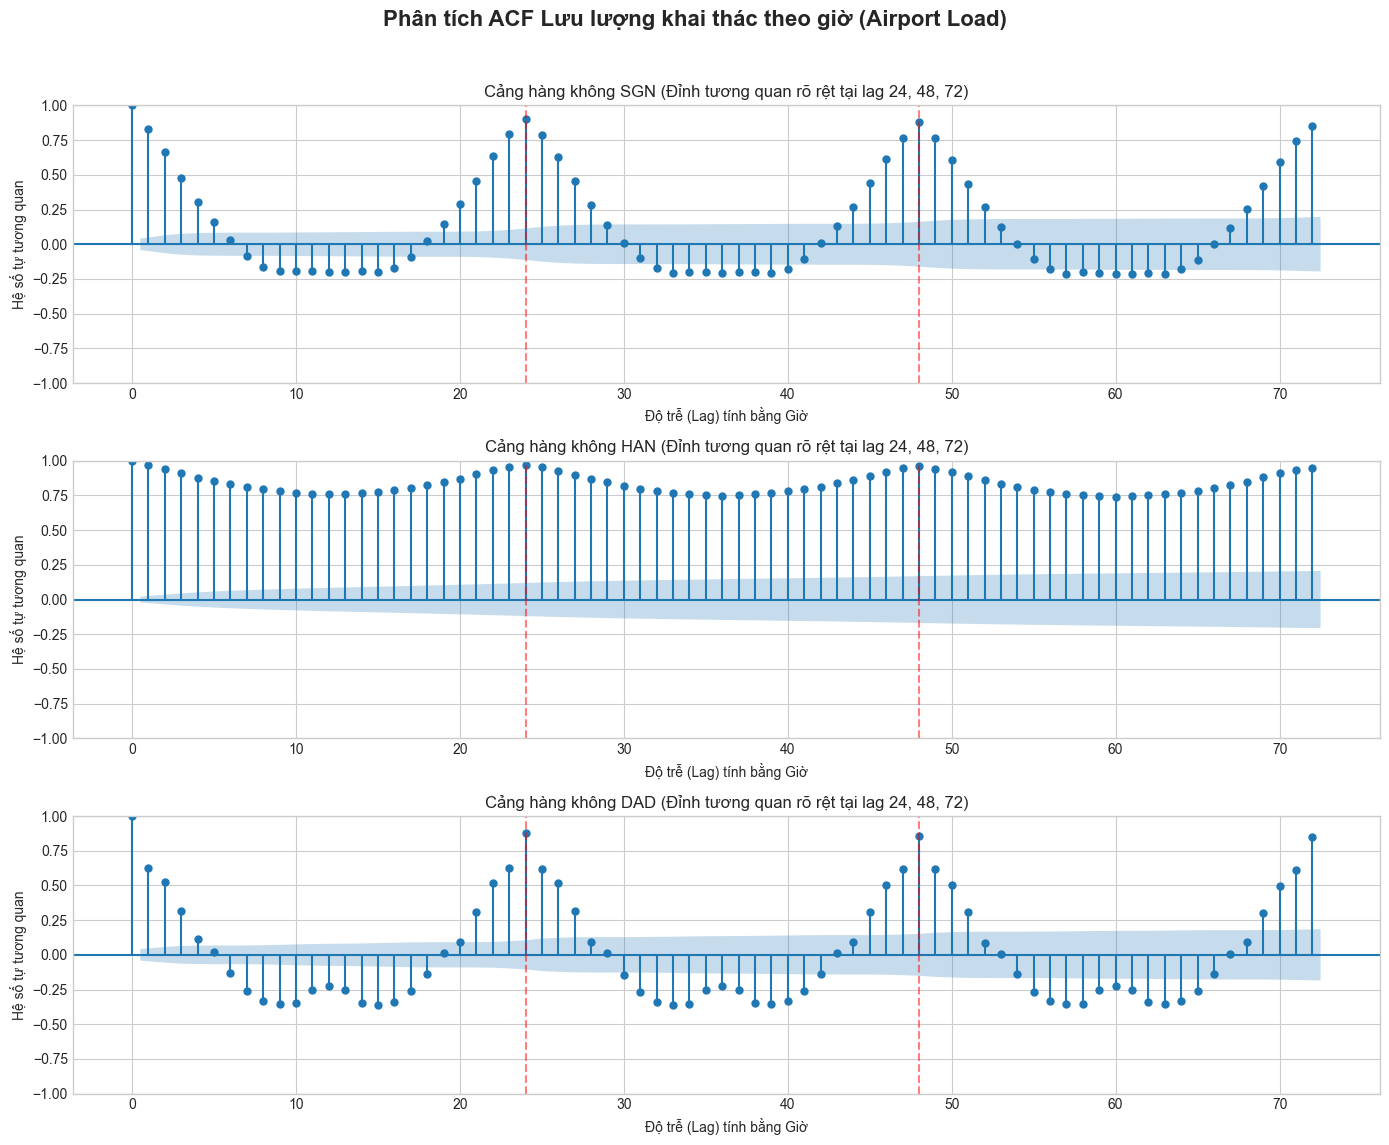

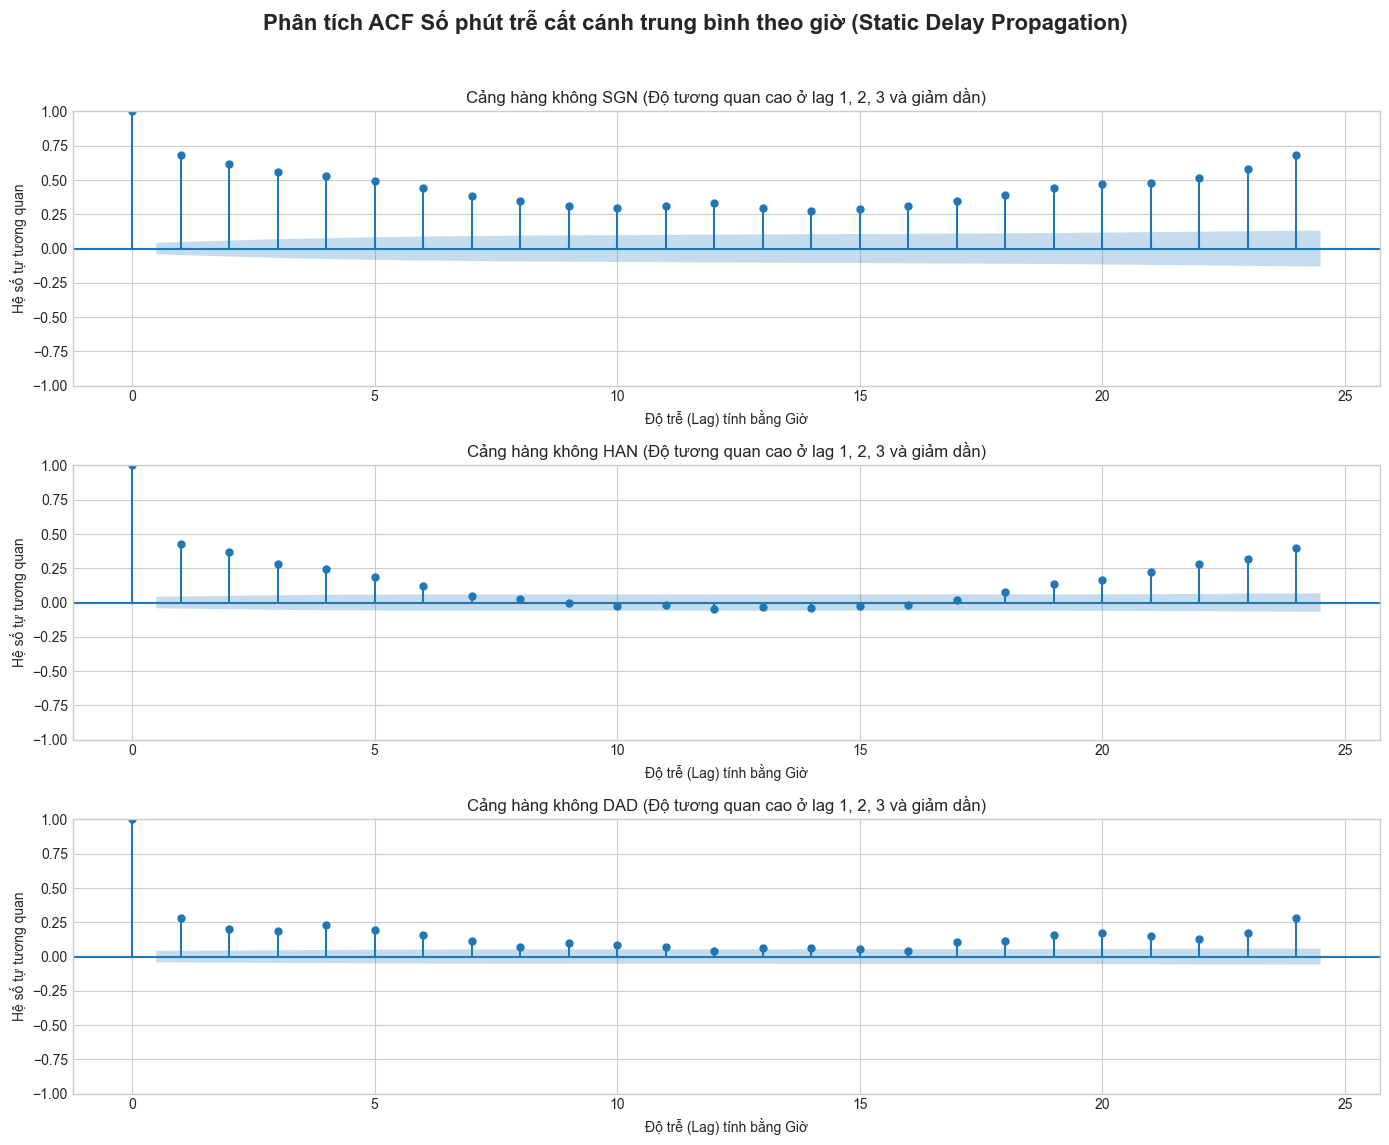

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

def plot_aerodelay_acf(app_deps, app_arrs):
    plt.style.use('seaborn-v0_8-whitegrid')
    airports = ['SGN', 'HAN', 'DAD']

    # Chuẩn bị dữ liệu thời gian
    deps = app_deps[['Origin', 'Scheduled_Time', 'Departure_Delay_Reg_Target']].copy()
    arrs = app_arrs[['Destination', 'Actual_Time']].copy()

    deps['Scheduled_Time'] = pd.to_datetime(deps['Scheduled_Time'], errors='coerce')
    arrs['Actual_Time'] = pd.to_datetime(arrs['Actual_Time'], errors='coerce')

    deps['Hour'] = deps['Scheduled_Time'].dt.floor('h')
    arrs['Hour'] = arrs['Actual_Time'].dt.floor('h')

    deps_load = deps[['Origin', 'Hour']].rename(columns={'Origin': 'Airport'})
    arrs_load = arrs[['Destination', 'Hour']].rename(columns={'Destination': 'Airport'})
    all_flights = pd.concat([deps_load, arrs_load], ignore_index=True)

    # 1. BIỂU ĐỒ ACF LƯU LƯỢNG CHỊU TẢI SÂN BAY (TÍNH CHU KỲ 24H)
    fig1, axes1 = plt.subplots(3, 1, figsize=(14, 12))
    fig1.suptitle('Phân tích ACF Lưu lượng khai thác theo giờ (Airport Load)', fontsize=16, fontweight='bold', y=0.95)

    for i, apt in enumerate(airports):
        # Giờ đây cột 'Airport' đã tồn tại hợp lệ
        apt_flights = all_flights[all_flights['Airport'] == apt]
        hourly_load = apt_flights.groupby('Hour').size()

        # Nội suy các giờ trống (không có chuyến bay) bằng 0 để giữ tính liên tục
        full_range = pd.date_range(start=hourly_load.index.min(), end=hourly_load.index.max(), freq='h')
        hourly_load = hourly_load.reindex(full_range, fill_value=0)

        # Vẽ ACF với lag = 72 (3 ngày)
        plot_acf(hourly_load, lags=72, ax=axes1[i], title=f'Cảng hàng không {apt} (Đỉnh tương quan rõ rệt tại lag 24, 48, 72)')
        axes1[i].set_ylabel('Hệ số tự tương quan')
        axes1[i].set_xlabel('Độ trễ (Lag) tính bằng Giờ')
        axes1[i].axvline(x=24, color='r', linestyle='--', alpha=0.5)
        axes1[i].axvline(x=48, color='r', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # 2. BIỂU ĐỒ ACF ĐỘ TRỄ CHUYẾN TÍCH LŨY (HIỆN TƯỢNG LAN TRUYỀN TĨNH)
    fig2, axes2 = plt.subplots(3, 1, figsize=(14, 12))
    fig2.suptitle('Phân tích ACF Số phút trễ cất cánh trung bình theo giờ (Static Delay Propagation)', fontsize=16, fontweight='bold', y=0.95)

    deps_valid_delay = deps.dropna(subset=['Departure_Delay_Reg_Target'])

    for i, apt in enumerate(airports):
        # Tính trung bình số phút trễ trong mỗi khung giờ
        apt_deps = deps_valid_delay[deps_valid_delay['Origin'] == apt]
        hourly_delay = apt_deps.groupby('Hour')['Departure_Delay_Reg_Target'].mean()

        # Nội suy các giờ không có chuyến bằng 0
        full_range_delay = pd.date_range(start=hourly_delay.index.min(), end=hourly_delay.index.max(), freq='h')
        hourly_delay = hourly_delay.reindex(full_range_delay, fill_value=0)

        # Vẽ ACF với lag = 24
        plot_acf(hourly_delay, lags=24, ax=axes2[i], title=f'Cảng hàng không {apt} (Độ tương quan cao ở lag 1, 2, 3 và giảm dần)')
        axes2[i].set_ylabel('Hệ số tự tương quan')
        axes2[i].set_xlabel('Độ trễ (Lag) tính bằng Giờ')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Thực thi hàm vẽ biểu đồ
app_deps = pd.read_csv(engineer.master_output_path)
airports = ['sgn', 'han', 'dad']
arr_list = []
for apt in airports:
    arr_file = engineer.gold_arrival_path / f"{apt}_flights_arrival_gold_layer.csv"

    if arr_file.exists():
        df_arr = pd.read_csv(arr_file)
        df_arr['Destination'] = apt.upper()
        arr_list.append(df_arr)
app_arrs = pd.concat(arr_list, ignore_index=True)
plot_aerodelay_acf(app_deps, app_arrs)

### PHÂN TÍCH PHÂN RĂ CHUỖI THỜI GIAN (STL DECOMPOSITION)
Chứng minh cơ sở thiết kế đặc trưng Thời gian (Temporal) và Thời tiết (Weather)

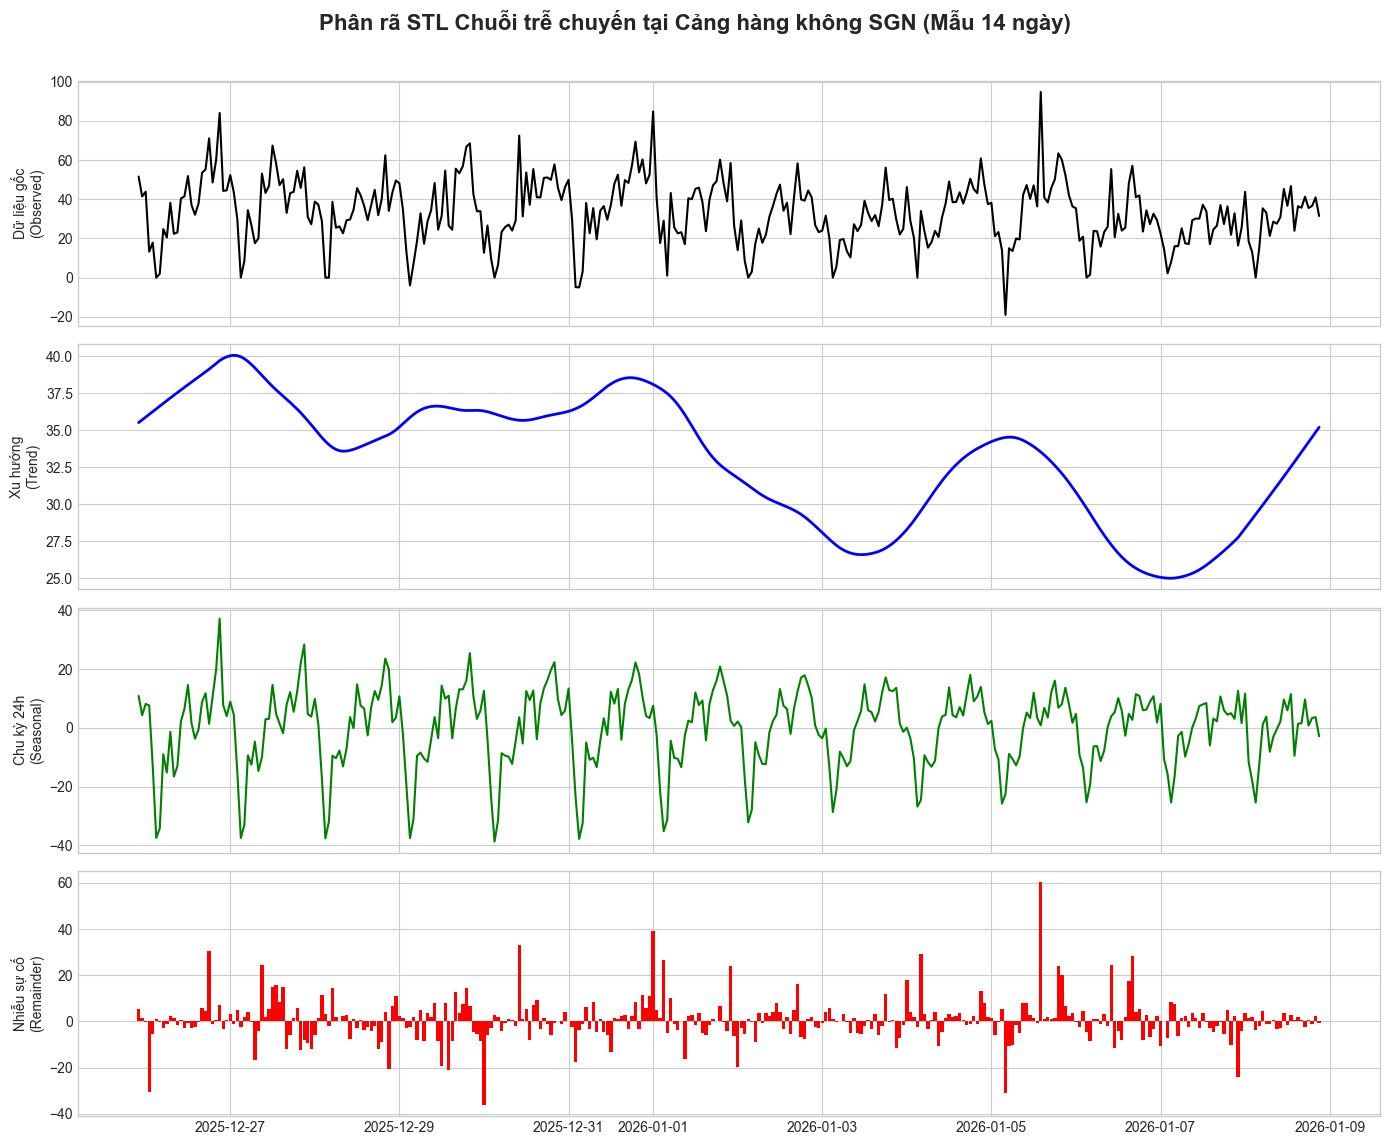

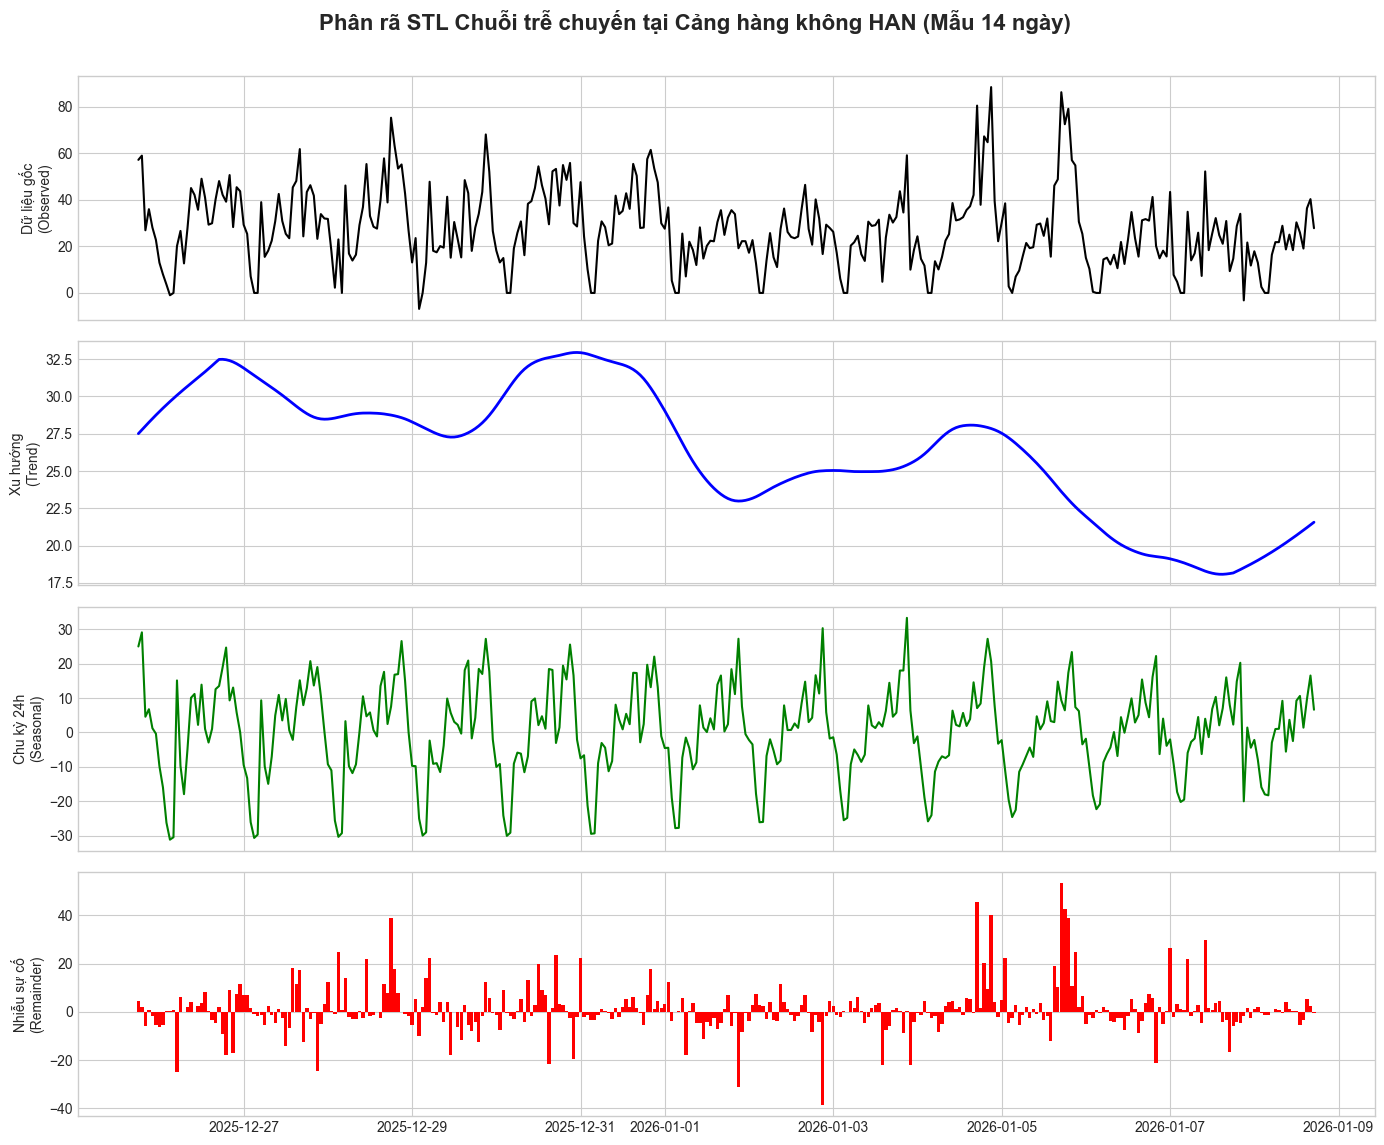

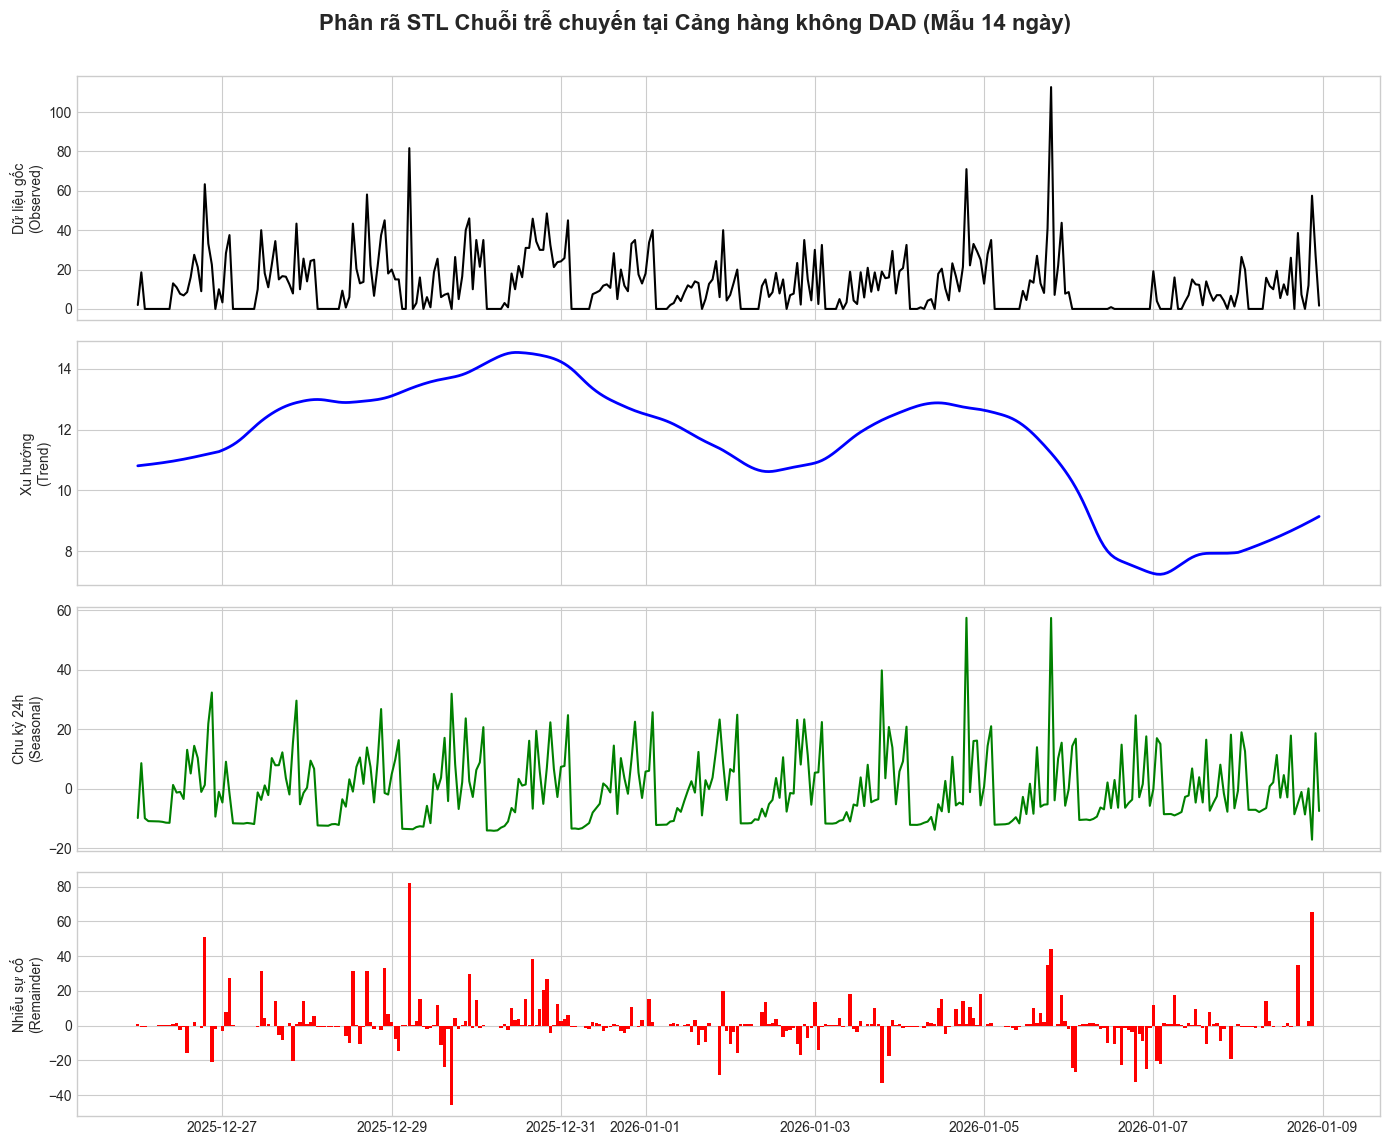

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def plot_aerodelay_stl(app_deps):
    plt.style.use('seaborn-v0_8-whitegrid')
    airports = ['SGN', 'HAN', 'DAD']

    # 1. Chuẩn bị dữ liệu thời gian (Giống hệt cách làm của hàm ACF)
    deps = app_deps[['Origin', 'Scheduled_Time', 'Departure_Delay_Reg_Target']].copy()
    deps['Scheduled_Time'] = pd.to_datetime(deps['Scheduled_Time'], errors='coerce')
    deps['Hour'] = deps['Scheduled_Time'].dt.floor('h')

    # Loại bỏ các dòng không có nhãn trễ
    deps_valid_delay = deps.dropna(subset=['Departure_Delay_Reg_Target'])

    for apt in airports:
        # 2. Tính trung bình số phút trễ trong mỗi khung giờ theo từng sân bay
        apt_deps = deps_valid_delay[deps_valid_delay['Origin'] == apt]
        hourly_delay = apt_deps.groupby('Hour')['Departure_Delay_Reg_Target'].mean()

        # 3. Nội suy các giờ không có chuyến bằng 0
        full_range_delay = pd.date_range(start=hourly_delay.index.min(), end=hourly_delay.index.max(), freq='h')
        hourly_delay = hourly_delay.reindex(full_range_delay, fill_value=0)

        # 4. Rút gọn mẫu dữ liệu để vẽ (Lấy 14 ngày = 336 giờ)
        # Nếu vẽ cả 3 tháng thì sóng chu kỳ sẽ bị đen đặc lại không thể nhìn bằng mắt thường
        # Lấy từ giờ thứ 240 trở đi để tránh nhiễu ở những ngày đầu tiên
        sample_delay = hourly_delay.iloc[240 : 240 + 24*14]

        # 5. Chạy thuật toán phân rã STL với chu kỳ 24h
        stl = STL(sample_delay, period=24, robust=True)
        res = stl.fit()

        # 6. Trực quan hóa 4 thành phần
        fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
        fig.suptitle(f'Phân rã STL Chuỗi trễ chuyến tại Cảng hàng không {apt} (Mẫu 14 ngày)', fontsize=16, fontweight='bold', y=0.95)

        # Thành phần 1: Dữ liệu gốc
        axes[0].plot(res.observed, color='black', linewidth=1.5)
        axes[0].set_ylabel('Dữ liệu gốc\n(Observed)')

        # Thành phần 2: Xu hướng
        axes[1].plot(res.trend, color='blue', linewidth=2)
        axes[1].set_ylabel('Xu hướng\n(Trend)')

        # Thành phần 3: Sóng chu kỳ 24h
        axes[2].plot(res.seasonal, color='green', linewidth=1.5)
        axes[2].set_ylabel('Chu kỳ 24h\n(Seasonal)')

        # Thành phần 4: Nhiễu ngẫu nhiên (Thời tiết/Sự cố)
        axes[3].bar(res.resid.index, res.resid, color='red', width=0.04)
        axes[3].set_ylabel('Nhiễu sự cố\n(Remainder)')

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

# Thực thi hàm (Vì biến app_deps đã được bạn khai báo ở trên nên gọi trực tiếp luôn)
plot_aerodelay_stl(app_deps)

### Cơ chế Xử lý Khuyết Giữa Arrival và Departure và Đồng bộ Chuỗi Xoay Vòng (Tail Rotation)
Máy bay vận hành theo chuỗi tịnh tiến: Hạ cánh (Arrival) -> Quay đầu (Turnaround) -> Cất cánh (Departure)
*  Tuy nhiên, dữ liệu cào (crawl) thực tế bị khuyết khoảng 1.5% số chuyến (Ví dụ: tàu bay bay charter không có lịch cố định).
*  Giải pháp toán học trong code:
1. Hàm pd.merge_asof(..., direction="backward") sẽ tự động tìm kiếm chặng hạ cánh gần nhất của chính cái đuôi tàu bay đó (Tail_Number) trong quá khứ để làm điểm tựa thời gian.
2. Với các chuyến bị missing (đã được đánh cờ Is_Imputed_Link = 1 thông qua file Audit), hệ thống không xóa bỏ mà tự động tính toán thời gian quay đầu trung vị (Median_Turnaround_Time) của phân khúc tàu bay đó tại sân bay đó làm thời gian đệm giả định.
3. Nhờ vậy, dòng thời gian thực tế chặng trước được bắc cầu sang chặng sau một cách hoàn hảo, giúp biến tích lũy trễ Accumulated_Delay không bị ngắt quãng.

In [10]:
# BƯỚC 2: Xử lý chuỗi xoay vòng (Khắc phục lỗi đứt link và tính delay)
engineer.build_tail_rotation_features()
display(engineer.features[['Flight_No', 'Scheduled_Time', 'Actual_Time', 'Turnaround_Buffer']].sample(10, random_state=108))

[*] 2/7: Đang xây dựng chuỗi xoay vòng tàu bay (Tail Rotation - Ngưỡng kẹp biên 72h)...
[V] Xử lý thành công dữ liệu xoay vòng (Đã tối ưu hóa dải phân phối cho chặng bay quốc tế).


,Flight_No,Scheduled_Time,Actual_Time,Turnaround_Buffer
9794,CZ8470,2026-01-14 16:10:00,2026-01-14 16:18:00,78
50407,VN1374,2026-01-24 15:45:00,2026-01-24 16:04:00,78
33522,VN506,2025-12-21 12:45:00,2025-12-21 12:42:00,65
34820,VN7102,2026-02-27 01:58:00,2026-02-27 01:58:00,59
20157,UA153,2026-03-11 06:00:00,2026-03-11 06:05:00,405
28344,VN643,2026-02-01 22:50:00,2026-02-01 23:16:00,44
39755,VJ803,2026-01-20 11:30:00,2026-01-20 12:01:00,287
47114,VN135,2026-02-09 17:30:00,2026-02-09 18:05:00,5
34021,VN7112,2026-02-03 22:35:00,2026-02-03 22:40:00,99
71539,VN249,2026-03-10 15:30:00,2026-03-10 15:50:00,327


### Rolling Window bằng Vector hóa
*  Thông thường, để tính mật độ sân bay trong khung giờ 30 phút hoặc 60 phút qua, chúng ta hay dùng hàm .rolling() của Pandas. Tuy nhiên, cách này bắt buộc phải tạo Index thời gian rất nặng và chạy vòng lặp cực kỳ chậm.
* Giải pháp tối ưu hóa:
	1.	Mã nguồn chuyển toàn bộ trục thời gian sang mảng một chiều của Numpy dưới định dạng số nguyên nano giây (datetime64[ns]) và tiến hành sắp xếp tăng dần (np.sort).
	2.	Hàm _count_between sử dụng thuật toán Tìm kiếm nhị phân (np.searchsorted) để xác định ngay lập tức vị trí con trỏ đầu và con trỏ cuối của mốc thời gian (Ví dụ: Vị trí của ‭$T - 30$‬‭‬ phút và ‭$T + 30$‬‭‬ phút).
	3. Số lượng chuyến bay trong khung giờ đó đơn giản là phép trừ vị trí: right_index - left_index (Độ phức tạp thuật toán giảm từ ‭$\mathcal{O}(N^2)$‬‭‬‭‬‭‬ xuống ‭$\mathcal{O}(N \log N)$‬‭‬‭‬‭‬‭‬‭‬). Phương pháp này giúp Notebook chạy nhanh hơn gấp 50 lần so với lệnh apply truyền thống.

In [11]:
# BƯỚC 3 & 4: Tính toán mật độ sân bay (Dùng hàm search nhị phân cực nhanh) và các biến Vận hành
engineer.build_airport_infrastructure_features()
engineer.build_airline_performance_features()
engineer.build_operational_and_holiday_features()
display(engineer.features[['Flight_No', 'Airport_Load_Factor', 'Is_Wide_Body', 'Time_of_Day']].sample(10, random_state=108))

[*] 3/8: Đang trích xuất đặc trưng Hạ tầng (CAAV) & Network Disruption...
[V] Đã hoàn tất đo lường tải trọng sân bay và Network Disruption.
[*] Đang tính toán Airline_Avg_Delay_Rate (availability-safe)...
[V] Đã hoàn tất đặc trưng Hiệu suất Hãng bay (Airline Performance).
[*] 4/8: Đang lập lịch đặc trưng Vận hành và Lễ Tết...


,Flight_No,Airport_Load_Factor,Is_Wide_Body,Time_of_Day
9794,CZ8470,0.513514,0,Afternoon
50407,VN1374,0.522727,0,Afternoon
33522,VN506,0.486486,0,Afternoon
34820,VN7102,0.522727,0,Early_Morning
20157,UA153,0.227273,1,Morning
28344,VN643,0.432432,0,Night
39755,VJ803,0.500000,0,Morning
47114,VN135,0.333333,0,Afternoon
34021,VN7112,0.500000,0,Night
71539,VN249,0.216216,1,Afternoon


### Trích xuất đặc trưng A-CDM & Network Effect
Để mô phỏng hệ thống điều hành sân bay (AODB), chúng ta xây dựng 4 biến số quan trọng dựa trên tài liệu Airport CDM Implementation:
- **A_CDM_TOBT_Deficit**: Dự báo sự chậm trễ dây chuyền do tàu bay đáp muộn.
- **Ground_Handling_Pressure**: Đo lường sự cạnh tranh nguồn lực mặt đất của cùng một hãng.
- **Destination_Congestion_Risk**: Nắm bắt sự trễ chuyến do ảnh hưởng từ hạ tầng sân bay đích (Network Effect).
- **Taxi_Out_Congestion**: Đo lường sự chậm trễ trong việc lăn bánh ra đường băng do mật độ sân bay cao.

In [12]:
# BƯỚC 5 & 6 & 7 & 8: Hoàn thiện dữ liệu, Kiểm định và Xuất file
engineer.build_acdm_network_features()
display(engineer.features[['Flight_No', 'A_CDM_TOBT_Deficit', 'Ground_Handling_Pressure', 'Destination_Congestion_Risk', 'Taxi_Out_Congestion']].sample(10, random_state=100))
engineer.build_arrival_feature_rows()
weather_path = engineer.gold_path / 'Features' / 'weather_features_hourly_gold.csv'
if os.path.exists(weather_path):
    engineer.build_weather_features(weather_path)
else:
    print('LƯU Ý: Không tìm thấy file thời tiết tại', weather_path, '. Vui lòng cập nhật đường dẫn.')
engineer.evaluate_features_quality()
engineer.export_gold_outputs()
print("Toàn bộ luồng dữ liệu đã chạy trơn tru.")

[*] 5/8: Đang trích xuất đặc trưng A-CDM & Network Effect...
[V] Đã xử lý xong các đặc trưng A-CDM (Cập nhật Ngưỡng động thành công).


,Flight_No,A_CDM_TOBT_Deficit,Ground_Handling_Pressure,Destination_Congestion_Risk,Taxi_Out_Congestion
10681,HO1328,0.0,0,0,0
21279,5J745,0.0,0,0,0
48399,VN136,0.0,9,0,0
8525,CA408,0.0,0,0,0
30873,VN1553,24.0,4,0,0
69029,VN306,3.0,3,0,0
23093,VU635,0.0,0,0,0
67546,VN250,45.0,8,0,0
26203,9G927,0.0,1,0,0
13836,KE458,0.0,0,0,0


[*] 6/8: Đang map feature tích lũy vào các chuyến hạ cánh...
[*] 7/8: Đang tích hợp bộ đặc trưng Khí tượng CAO CẤP từ /Users/nguyenhung/PycharmProjects/DS108/Data/Gold_layer/Features/weather_features_hourly_gold.csv...
[V] Hoàn tất tích hợp Khí tượng (Đã xử lý triệt để lỗi Null Keys).
[*] 7.5/8: Đang kiểm tra (Data Leakage & Imputation)...
[V] Xác thực Temporal Leakage thành công: 0 dòng vi phạm.
[V] Đã cập nhật audit: temporal_data_leakage_report.csv, imputation_metrics_log.csv, feature_summary_stats.csv
[*] 8/8: Đang xuất bản dữ liệu sạch sang Gold Layer...
    - Drop khi Departure SGN: ['Matched_Actual_Tail', 'Swap_Match_Gap_Minutes']
    - Drop khi Departure HAN: ['Matched_Actual_Tail', 'Swap_Match_Gap_Minutes']
    - Drop khi Departure DAD: ['Matched_Actual_Tail', 'Swap_Match_Gap_Minutes']
[V] TIẾN TRÌNH HOÀN TẤT! Dữ liệu Master được gộp từ 3 file lẻ và lưu tại: /Users/nguyenhung/PycharmProjects/DS108/Data/Gold_layer/Features/master_departure_features_gold.csv
Toàn bộ luồng dữ liệ